# Biases: CESM3 / MOM6 experiment comparison

Additional bias diagnostics for a set of coupled and forced experiments,
beyond the ones already covered in `key_diagnostics.ipynb`. The shared
`Experiment` class lives in `experiment.py` so it can be reused across
notebooks.

**Experiments compared**

| name | mode | data folder |
|------|------|-------------|
| `CTRL` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0_uANN_1.0` | coupled | `data/coupled_55years` |
| `forced_CTRL` | forced | `data/forced_55years` |
| `forced_bANN_1.0` | forced | `data/forced_55years` |
| `forced_bANN_1.0_uANN_1.0` | forced | `data/forced_55years` |

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).

In [2]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cftime

from experiment import Experiment

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 18})

# Repo-root-relative paths (this notebook lives in <repo>/notebooks)
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
COUPLED_DIR = os.path.join(REPO, 'data', 'coupled_55years')
FORCED_DIR = os.path.join(REPO, 'data', 'forced_55years')
FIG_DIR = os.path.join(REPO, 'figures', 'coupled_55years')

print('REPO       =', REPO)
print('YAML_DIR   =', YAML_DIR)
print('COUPLED_DIR=', COUPLED_DIR)
print('FORCED_DIR =', FORCED_DIR)

REPO       = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
YAML_DIR   = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/yamls
COUPLED_DIR= /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/coupled_55years
FORCED_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/forced_55years


## Initialize experiments (read-only)

Each experiment is defined by its `name`, the diagnostics YAML config, and the
folder holding its postprocessed NetCDF files. Initialization is read-only: it
only reads config + (best-effort) grid, and never triggers heavy computation.

In [3]:
# (name, folder) for each experiment. YAML config is yamls/<name>.yaml
experiment_defs = [
    ('CTRL',                        COUPLED_DIR),
    ('coupled_bANN_1.0',            COUPLED_DIR),
    ('coupled_bANN_1.0_uANN_1.0',   COUPLED_DIR),
    ('forced_CTRL',                 FORCED_DIR),
    ('forced_bANN_1.0',             FORCED_DIR),
    ('forced_bANN_1.0_uANN_1.0',    FORCED_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

exp_names = list(exps.keys())
coupled_names = ['coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'CTRL' ]
forced_names = ['forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0', 'forced_CTRL']

print('\nInitialized:', exp_names)

[CTRL] casename=CTRL, rundir=/glade/derecho/scratch/jiarongw/CTRL/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0] casename=coupled_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0_uANN_1.0] casename=coupled_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 

[forced_CTRL] casename=forced_CTRL, rundir=/glade/derecho/scratch/pavelp/forced_CTRL/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0] casename=forced_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0_uANN_1.0] casename=forced_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 


Initialized: ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']


In [4]:
# Short legend labels (regime is shown in the panel title, so it is omitted here)
LABELS = {
    'CTRL':                       'GM',
    'coupled_bANN_1.0':           'bANN',
    'coupled_bANN_1.0_uANN_1.0':  'bANN_uANN',
    'forced_CTRL':                'GM',
    'forced_bANN_1.0':            'bANN',
    'forced_bANN_1.0_uANN_1.0':   'bANN_uANN',
}

# 1. Mixed-layer depth (MLD) bias and response

Winter and summer mixed-layer depth bias (`model $-$ obs`) and response
(`exp $-$ GM`), drawn in the same 2×3 (coupled / forced) map style as Section 2
with a gray land background and a shared colorbar. Observed MLD is the de Boyer
Montégut (2023) climatology (`mld-deboyer-2023-tx2_3v2`), with winter/summer
constructed per hemisphere (NH winter = JFM, SH winter = JAS, and vice-versa for
summer), following
[compare_runs_coupled.ipynb](../notebooks-development/compare_runs_coupled.ipynb).
Column 1 shows the GM bias (`model $-$ obs`); columns 2–3 show each experiment's
response (`exp $-$ GM`). RMSE is always the area-weighted RMS of `model $-$ obs`.

In [56]:
# --- Section 1: winter/summer mixed-layer depth (MLD) bias and response ---
# Observed MLD: de Boyer Montegut (2023) climatology (mld-deboyer-2023-tx2_3v2),
# on the same tx2_3v2 grid as the model. Winter/summer are hemisphere-dependent:
# NH winter = JFM & SH winter = JAS (and the reverse for summer), following
# notebooks-development/compare_runs_coupled.ipynb.
%matplotlib inline
import intake
import matplotlib as mpl
from mom6_tools.m6plot import myStats

# GM control first in each row, then the two ANN experiments.
coupled_row = ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0']
forced_row = ['forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']

_mld_catalog = intake.open_catalog(
    '/glade/u/home/gmarques/libs/oce-catalogs/reference-datasets.yml')
_mld_obs = _mld_catalog['mld-deboyer-2023-tx2_3v2'].to_dask()
_mld_obs = _mld_obs.rename({'time': 'month'})
_mld_obs['month'] = np.arange(1, len(_mld_obs.month) + 1)

_grd = exps['CTRL'].grd
_obs_JFM = np.ma.masked_invalid(_mld_obs.mld.isel(month=[0, 1, 2]).mean('month').values)
_obs_JAS = np.ma.masked_invalid(_mld_obs.mld.isel(month=[6, 7, 8]).mean('month').values)
_j = int(np.abs(_grd.geolat[:, 0] - 0.0).argmin())      # equator row index
obs_mld_winter = _obs_JAS.copy()
obs_mld_summer = _obs_JAS.copy()
obs_mld_winter[_j:, :] = _obs_JFM[_j:, :]    # NH winter = JFM (SH winter = JAS)
obs_mld_summer[0:_j, :] = _obs_JFM[0:_j, :]  # SH summer = JFM (NH summer = JAS)
obs_mld_winter = obs_mld_winter.data + _grd.geolon * 0   # -> DataArray on (yh, xh)
obs_mld_summer = obs_mld_summer.data + _grd.geolon * 0

# Bias-map levels/colormap for MLD (matches compare_runs_coupled.ipynb).
# Summer MLD is much shallower, so it uses a tighter +/-20 m scale (vs +/-200 m
# for winter), following compare_runs_coupled.ipynb.
MLD_CMAP = plt.get_cmap('RdBu_r')
MLD_WINTER_LEVELS = np.linspace(-200, 200, 17)   # m
MLD_SUMMER_LEVELS = np.linspace(-20, 20, 17)     # m
MLD_WINTER_NORM = mpl.colors.BoundaryNorm(MLD_WINTER_LEVELS, MLD_CMAP.N, extend='both')
MLD_SUMMER_NORM = mpl.colors.BoundaryNorm(MLD_SUMMER_LEVELS, MLD_CMAP.N, extend='both')


def plot_bias_maps_2d(get_bias, norm, cmap, quantity, unit, cbar_label,
                      ref_label='WOA18'):
    """2x3 map of a 2D bias field (model - obs) and exp - GM response patterns.

    Mirrors ``plot_bias_maps`` (Section 2) but for a horizontal (yh, xh) field
    with no depth level. ``get_bias(exp)`` returns the 2D bias DataArray. RMSE is
    the area-weighted RMS of each experiment's bias against obs (exp - obs), even
    on panels that display the response pattern (exp - GM)."""
    fig, axes = plt.subplots(2, 3, figsize=(22, 12), dpi=150,
                             sharex=True, sharey=True, constrained_layout=True)
    pc = None
    for row, (regime, names) in enumerate([('Coupled', coupled_row),
                                           ('Forced', forced_row)]):
        gm_name = names[0]
        gm_bias = get_bias(exps[gm_name])
        for col, name in enumerate(names):
            ax = axes[row, col]
            exp = exps[name]
            bias = get_bias(exp)
            if col == 0:
                field = bias                     # GM control bias (model - obs)
                title = f'{regime}: {LABELS[name]} ' + r'$-$' + f' {ref_label}'
            else:
                field = bias - gm_bias           # response pattern (exp - GM)
                title = f'{regime}: {LABELS[name]} ' + r'$-$' + ' GM'
            area = np.ma.masked_invalid(exp.area)
            _, _, _, _, rmse = myStats(np.ma.masked_invalid(bias.values), area)
            # Plot on true geographic (lon, lat) coordinates from the MOM6 grid,
            # filling NaN land points in the coords (see plot_bias_maps).
            ydim, xdim = exp.grd.geolon.dims
            lon = (exp.grd.geolon.ffill(xdim).bfill(xdim)
                   .ffill(ydim).bfill(ydim).values)
            lat = (exp.grd.geolat.ffill(ydim).bfill(ydim)
                   .ffill(xdim).bfill(xdim).values)
            pc = ax.pcolormesh(lon, lat, np.ma.masked_invalid(field.values),
                               cmap=cmap, norm=norm, shading='auto')
            ax.set_facecolor('gray')
            ax.set_title(f'{title}\nRMSE={rmse:.1f} {unit}')
            ax.set_xlabel('Longitude' if row == 1 else '')
            ax.set_ylabel('Latitude' if col == 0 else '')
    cbar = fig.colorbar(pc, ax=axes, label=cbar_label, extend='both',
                        ticks=norm.boundaries, spacing='uniform',
                        shrink=0.85, pad=0.02)
    cbar.ax.set_yticklabels([f'{b:g}' for b in norm.boundaries])
    fig.suptitle(f'{quantity} bias (model $-$ {ref_label}) and response patterns',
                 fontsize=30)
    plt.show()


def plot_mld_winter():
    plot_bias_maps_2d(lambda e: e.mld_winter().MLD_winter - obs_mld_winter,
                      MLD_WINTER_NORM, MLD_CMAP, 'Winter MLD', 'm',
                      'Winter MLD bias or response [m]', ref_label='de Boyer 2023')


def plot_mld_summer():
    plot_bias_maps_2d(lambda e: e.mld_summer().MLD_summer - obs_mld_summer,
                      MLD_SUMMER_NORM, 'bwr', 'Summer MLD', 'm',
                      'Summer MLD bias or response [m]', ref_label='de Boyer 2023')

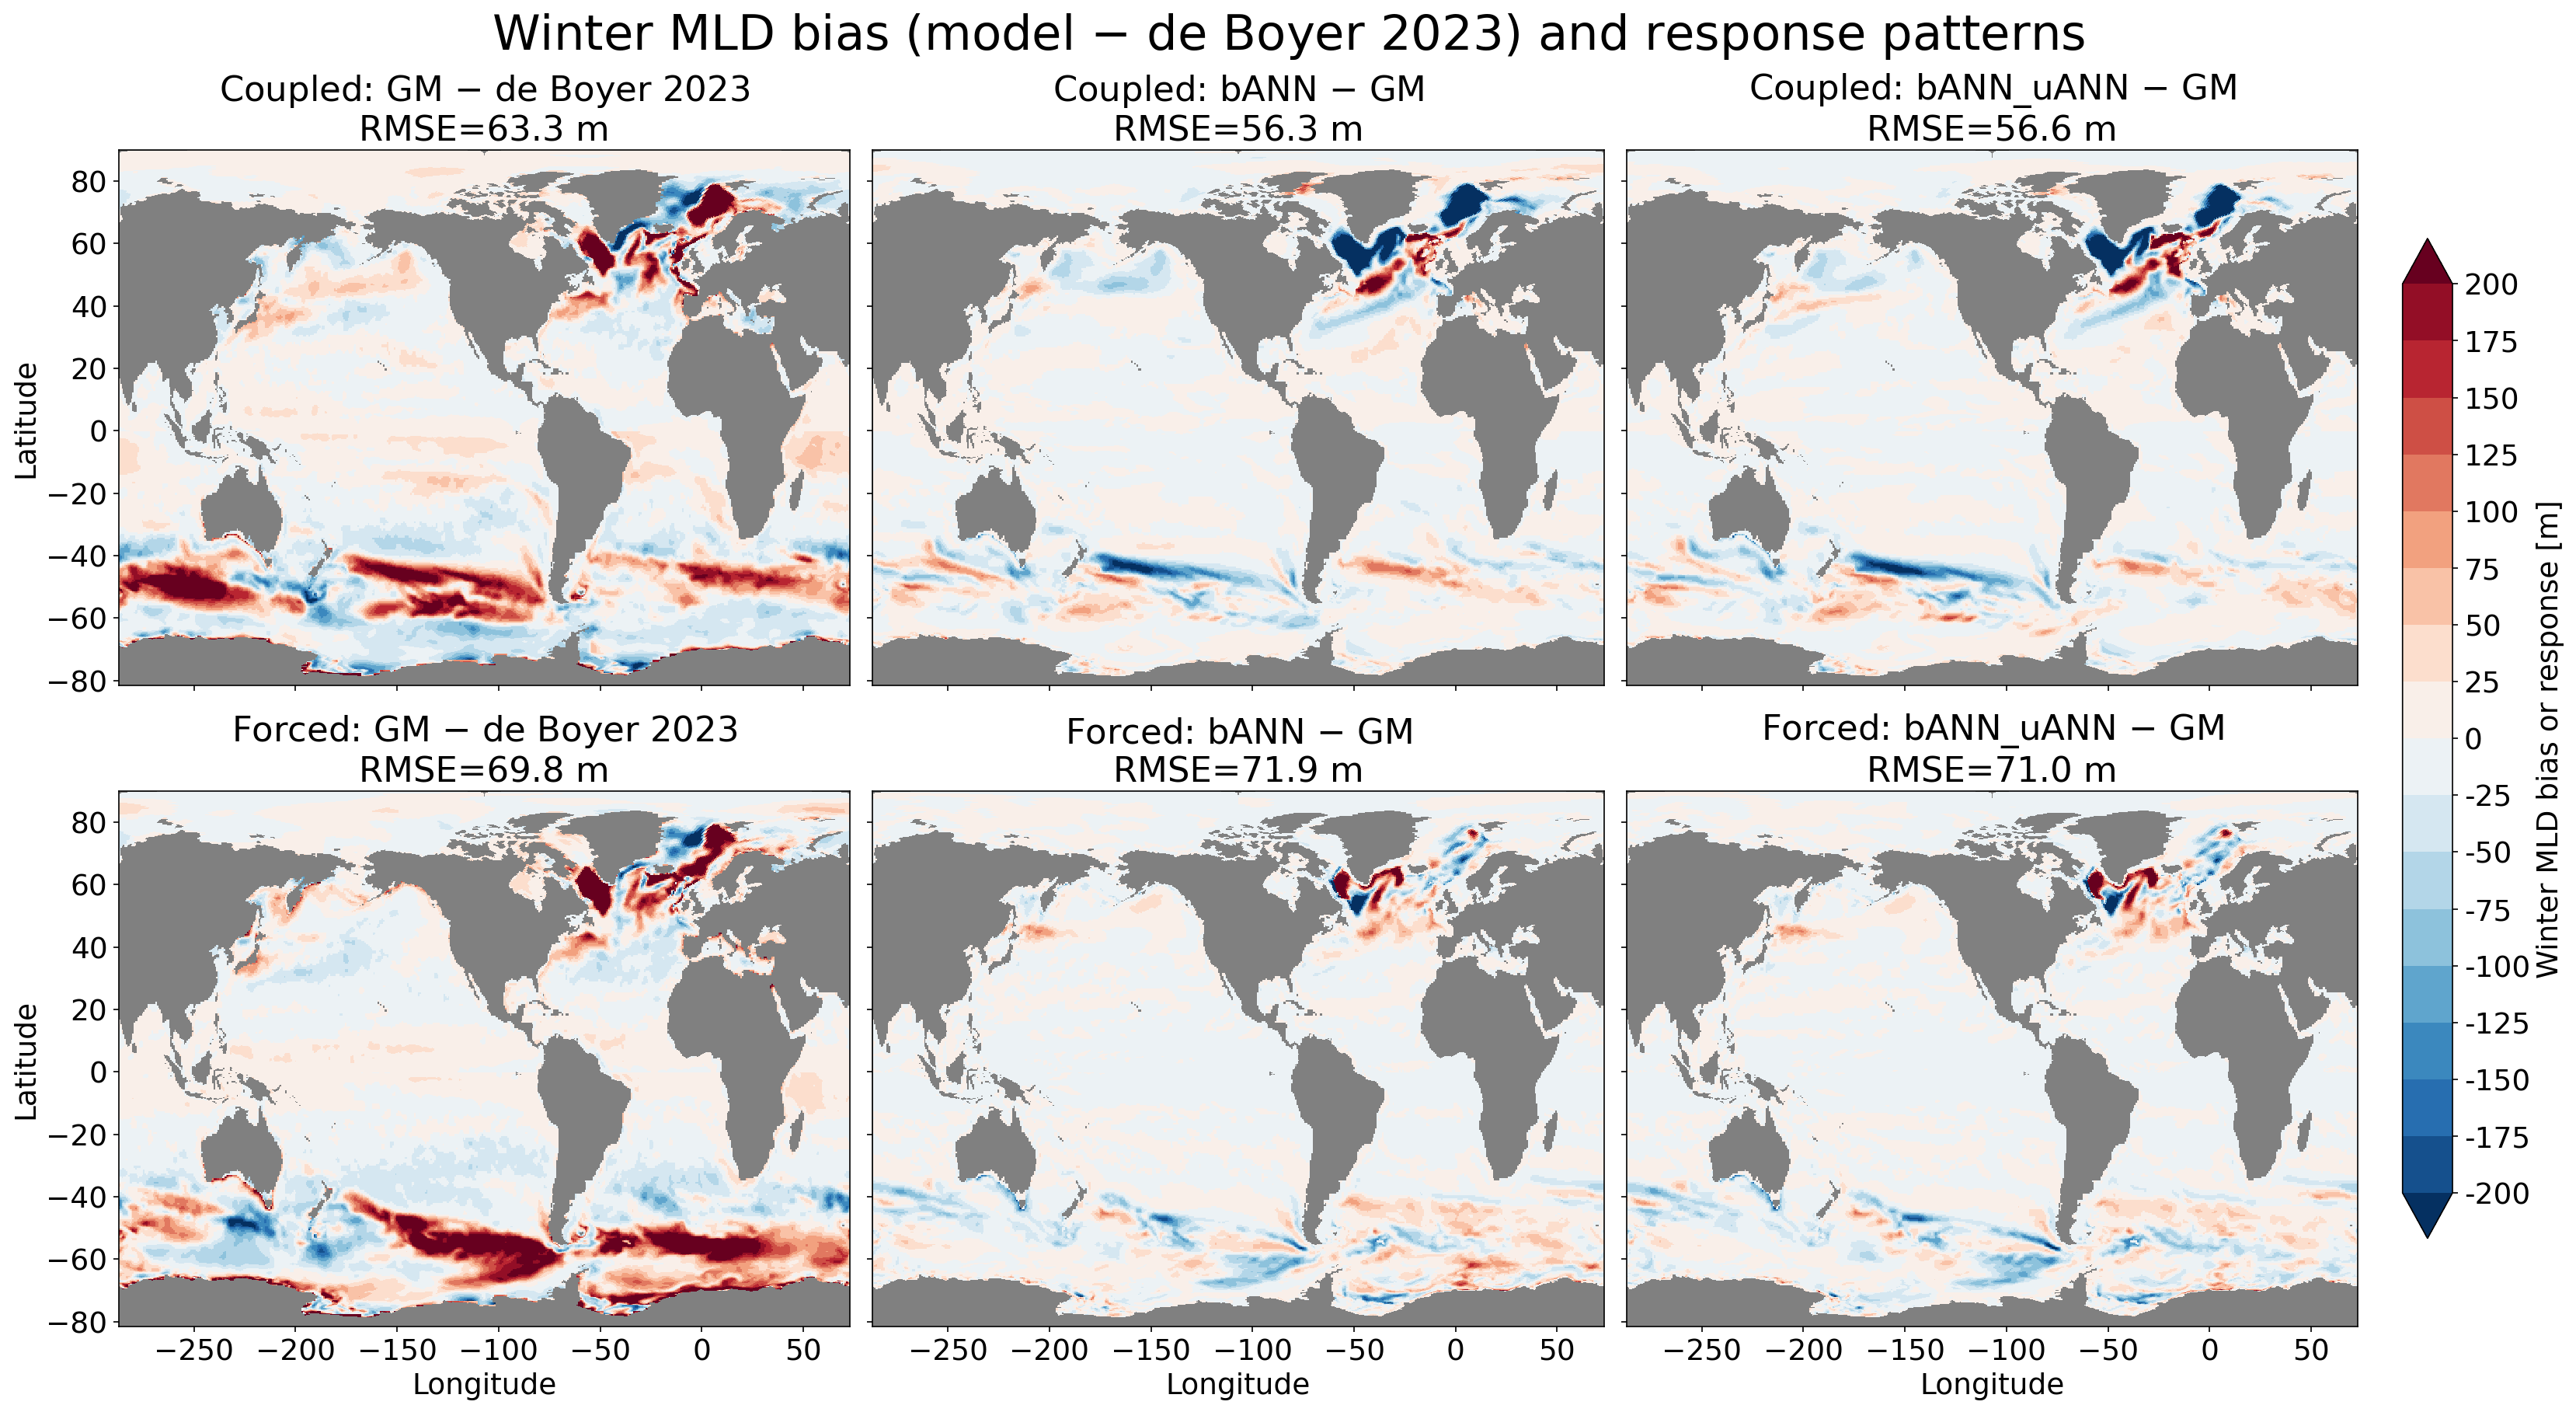

In [54]:
plot_mld_winter()

## Summer MLD

Same diagnostic for the summer season (SH summer = JFM, NH summer = JAS).

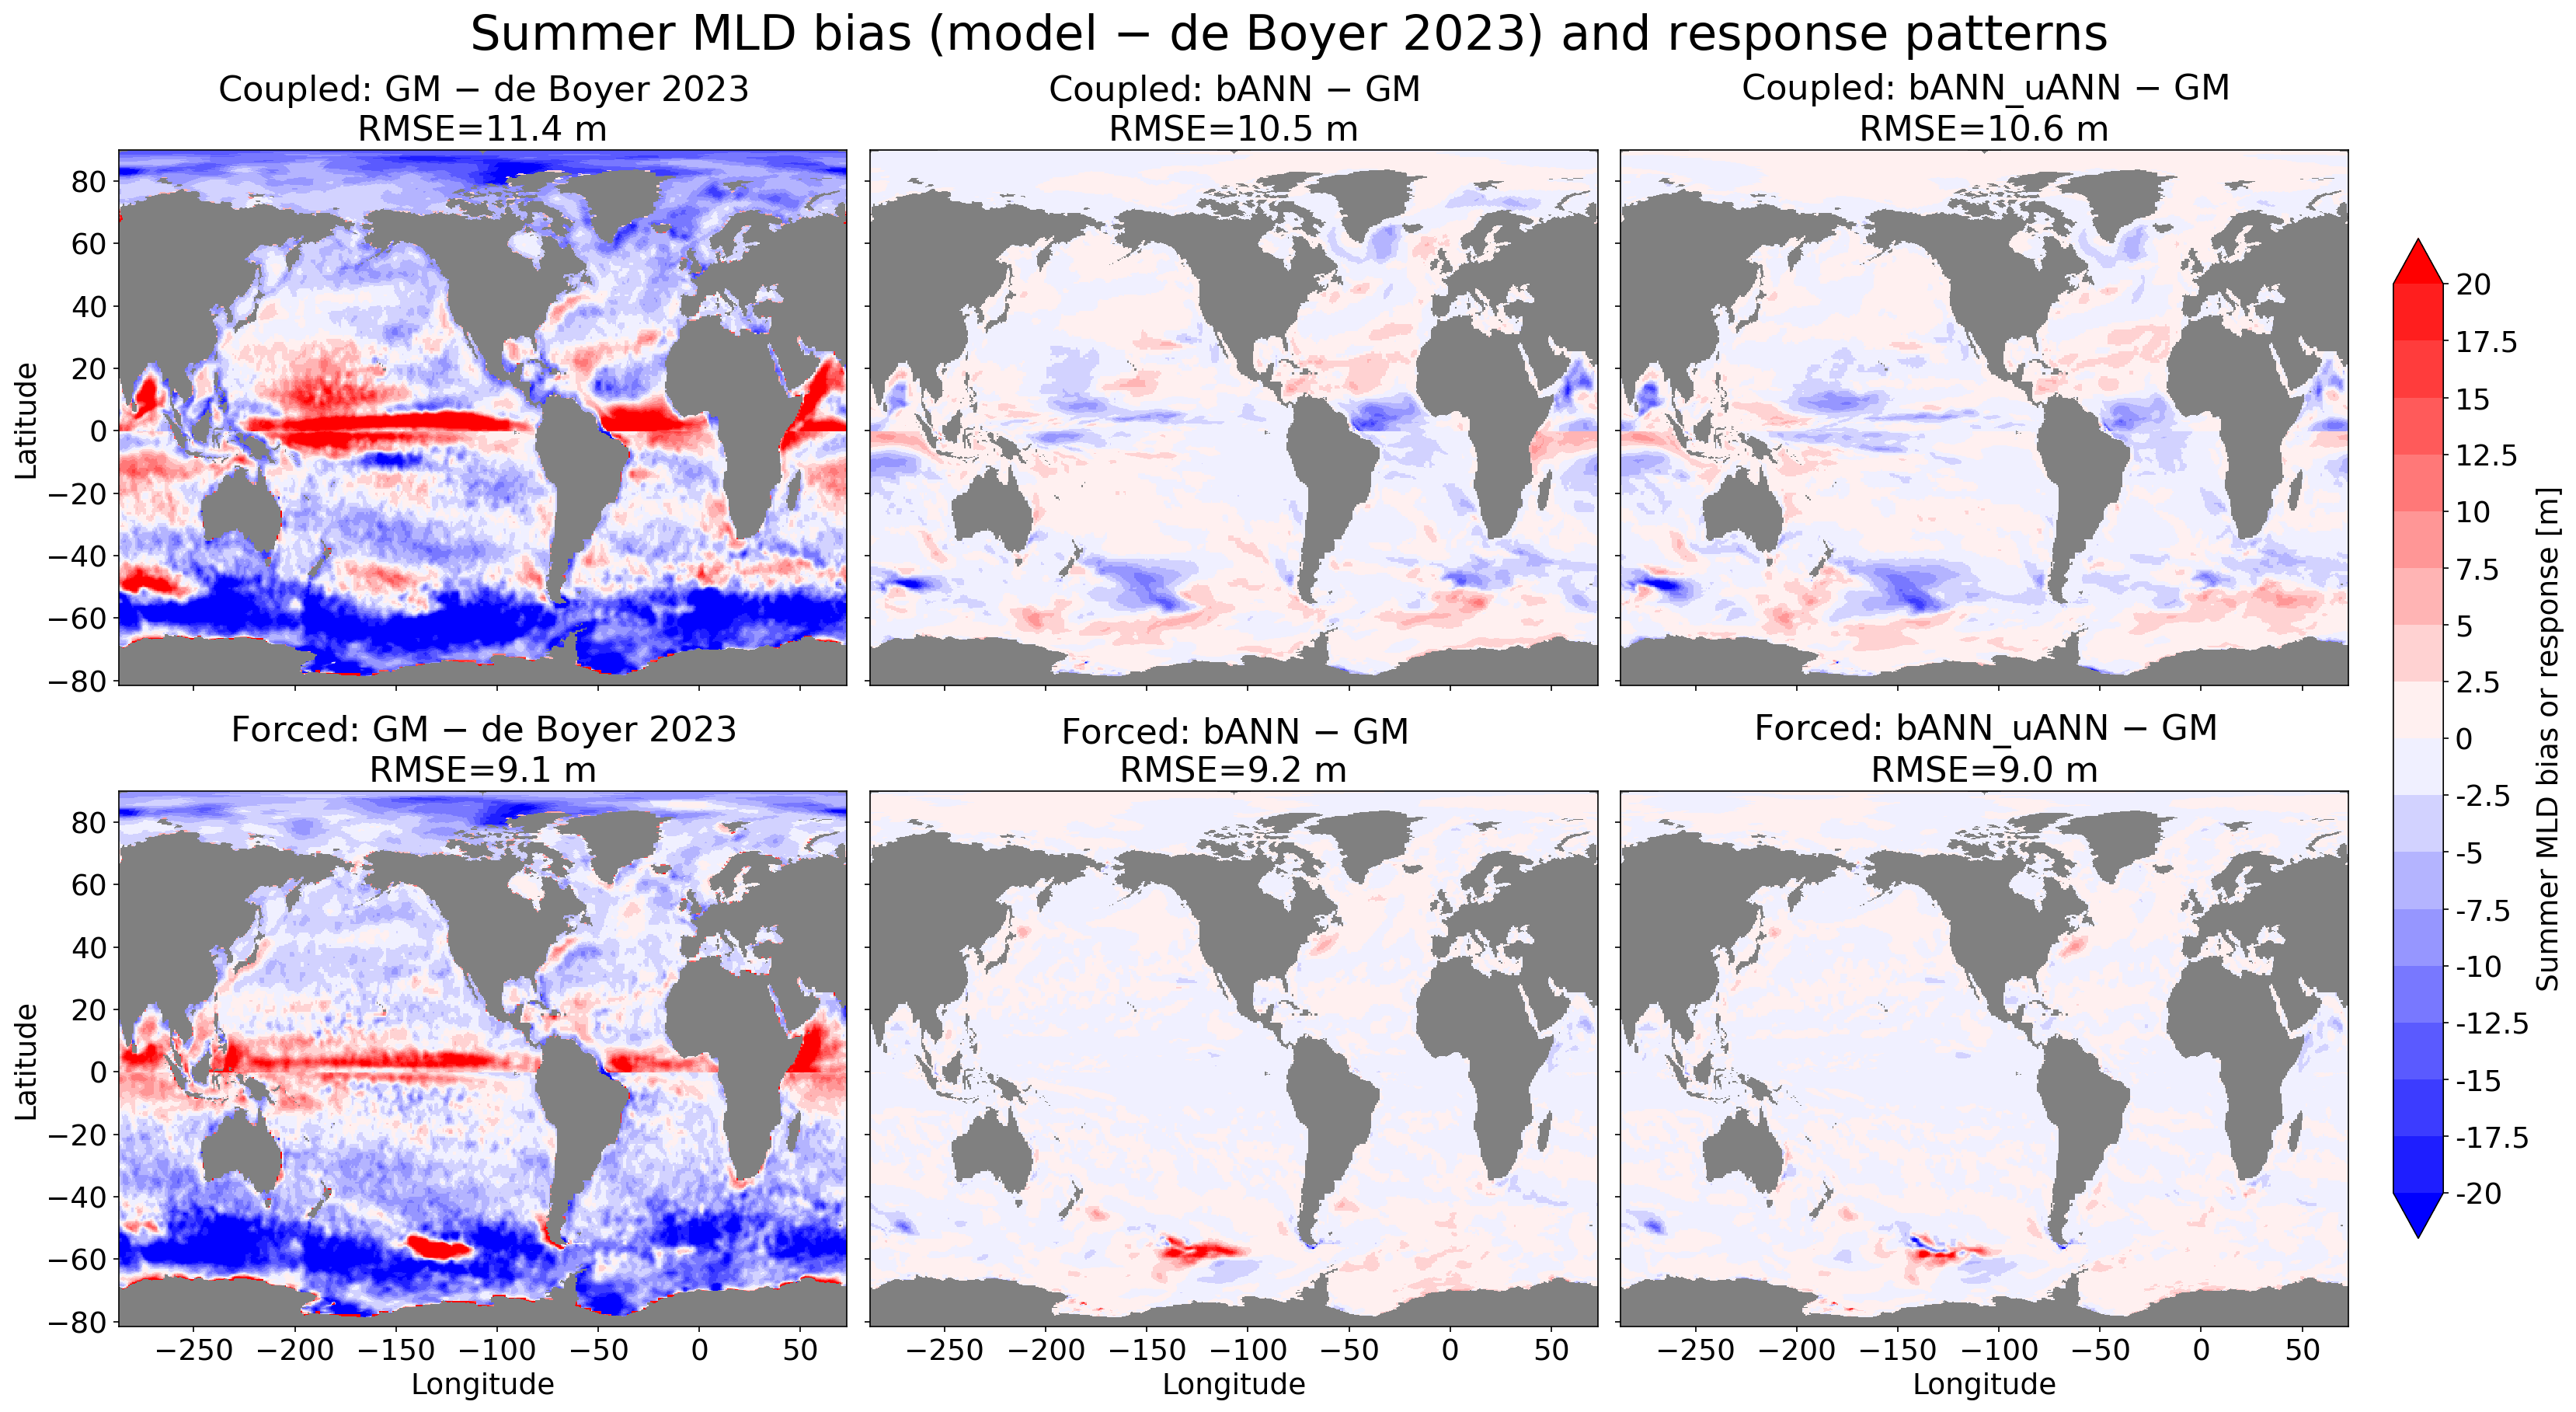

In [57]:
plot_mld_summer()

# 2. Temperature bias (model - WOA18)

Time-mean potential temperature bias against the WOA-2018 climatology
(`woa-2018-tx2_3v2-annual-all`), read directly from the precomputed
`thetao_bias` field in each experiment's `*_thetao_time_mean.nc`
(`model - WOA18`, generated by `mom6_tools.TS_levels`; see
[compare_runs_coupled.ipynb](../notebooks-development/compare_runs_coupled.ipynb)
for the original ad hoc version of this bias computation). Shown at the
surface level (`z_l` = 2.5 m). RMSE is the area-weighted RMS of the bias field
(`mom6_tools.m6plot.myStats`).

Same 2x3 grid / contourf / gray-land / shared-colorbar spatial-map style as
key_diagnostics.ipynb section 11 (surface epineutral diffusivity).

In [5]:
# Generic bias-map plotter, reused for temperature and salinity.
# Left column: GM control bias (model - WOA18).
# Other columns: response pattern of each experiment relative to GM (exp - GM).
%matplotlib inline
from mom6_tools.m6plot import myStats
import matplotlib as mpl

# GM control first in each row, then the two ANN experiments.
coupled_row = ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0']
forced_row = ['forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']


def plot_bias_maps(get_bias, target_depth, norm, cmap, quantity, unit,
                   cbar_label):
    """2x3 map of a bias field (model - WOA18) and exp - GM response patterns.

    ``get_bias(exp)`` returns the 3D bias DataArray (z_l, yh, xh) for an
    experiment. The nearest ``z_l`` level to ``target_depth`` (m) is selected.
    RMSE is always the area-weighted RMS of each experiment's bias against WOA18
    (exp - WOA18), even on panels that display the response pattern (exp - GM).
    """
    fig, axes = plt.subplots(2, 3, figsize=(22, 12), dpi=150,
                             sharex=True, sharey=True, constrained_layout=True)
    pc = None
    depth = None
    for row, (regime, names) in enumerate([('Coupled', coupled_row),
                                           ('Forced', forced_row)]):
        gm_name = names[0]
        gm_bias = get_bias(exps[gm_name]).sel(z_l=target_depth, method='nearest')
        for col, name in enumerate(names):
            ax = axes[row, col]
            exp = exps[name]
            bias = get_bias(exp).sel(z_l=target_depth, method='nearest')
            depth = round(float(bias.z_l), 1)
            if col == 0:
                field = bias                     # GM control bias (model - WOA18)
                title = f'{regime}: {LABELS[name]} ' + r'$-$' + ' WOA18'
            else:
                field = bias - gm_bias           # response pattern (exp - GM)
                title = f'{regime}: {LABELS[name]} ' + r'$-$' + ' GM'
            area = np.ma.masked_invalid(exp.area)
            _, _, _, _, rmse = myStats(np.ma.masked_invalid(bias.values), area)
            # Plot on true geographic (lon, lat) coordinates from the MOM6 grid.
            # pcolormesh requires finite X/Y; fill NaN land points in the coords
            # with nearest valid grid values so coastal cells aren't distorted.
            ydim, xdim = exp.grd.geolon.dims
            lon = (exp.grd.geolon.ffill(xdim).bfill(xdim)
                   .ffill(ydim).bfill(ydim).values)
            lat = (exp.grd.geolat.ffill(ydim).bfill(ydim)
                   .ffill(xdim).bfill(xdim).values)
            pc = ax.pcolormesh(lon, lat, np.ma.masked_invalid(field.values),
                               cmap=cmap, norm=norm, shading='auto')
            ax.set_facecolor('gray')
            ax.set_title(f'{title}\nRMSE={rmse:.2f} {unit}')
            ax.set_xlabel('Longitude' if row == 1 else '')
            ax.set_ylabel('Latitude' if col == 0 else '')
    cbar = fig.colorbar(pc, ax=axes, label=cbar_label, extend='both',
                        ticks=norm.boundaries, spacing='uniform',
                        shrink=0.85, pad=0.02)
    cbar.ax.set_yticklabels([f'{b:g}' for b in norm.boundaries])
    fig.suptitle(f'{quantity} bias (model $-$ WOA18) and response patterns, '
                 f'depth={depth} m', fontsize=30)
    plt.show()


# --- Temperature configuration ---
TBIAS_LEVELS = np.arange(-1.8, 1.81, 0.4)   # degC, matches compare_runs_coupled.ipynb
T_CMAP = plt.get_cmap('RdYlBu_r')
T_NORM = mpl.colors.BoundaryNorm(TBIAS_LEVELS, T_CMAP.N, extend='both')


def plot_thetao_bias_maps(target_depth):
    plot_bias_maps(lambda e: e.thetao().thetao_bias, target_depth,
                   T_NORM, T_CMAP, 'Temperature', r'$^\circ$C',
                   r'Temperature bias or response [$^\circ$C]')


# --- Salinity configuration ---
# Wide neutral central bin: |bias| < 0.1 PSU is drawn as a single neutral
# color instead of flipping hue across zero. Boundaries are uneven (a fat
# [-0.1, 0.1] bin) and the matching bin color is set to white.
SBIAS_LEVELS = np.array([-1.0, -0.8, -0.6, -0.4, -0.2, -0.1,
                         0.1, 0.2, 0.4, 0.6, 0.8, 1.0])   # PSU
_s_base = plt.get_cmap('RdYlBu_r')
_s_nbins = len(SBIAS_LEVELS) - 1
_s_colors = list(_s_base(np.linspace(0, 1, _s_nbins)))
_s_colors[_s_nbins // 2] = (1.0, 1.0, 1.0, 1.0)   # neutral for [-0.1, 0.1] PSU
S_CMAP = mpl.colors.ListedColormap(_s_colors)
S_CMAP.set_under(_s_base(0.0))
S_CMAP.set_over(_s_base(1.0))
S_NORM = mpl.colors.BoundaryNorm(SBIAS_LEVELS, S_CMAP.N)   # extend via colorbar


def plot_so_bias_maps(target_depth):
    plot_bias_maps(lambda e: e.so().so_bias, target_depth,
                   S_NORM, S_CMAP, 'Salinity', 'PSU',

                   'Salinity bias or response [PSU]')

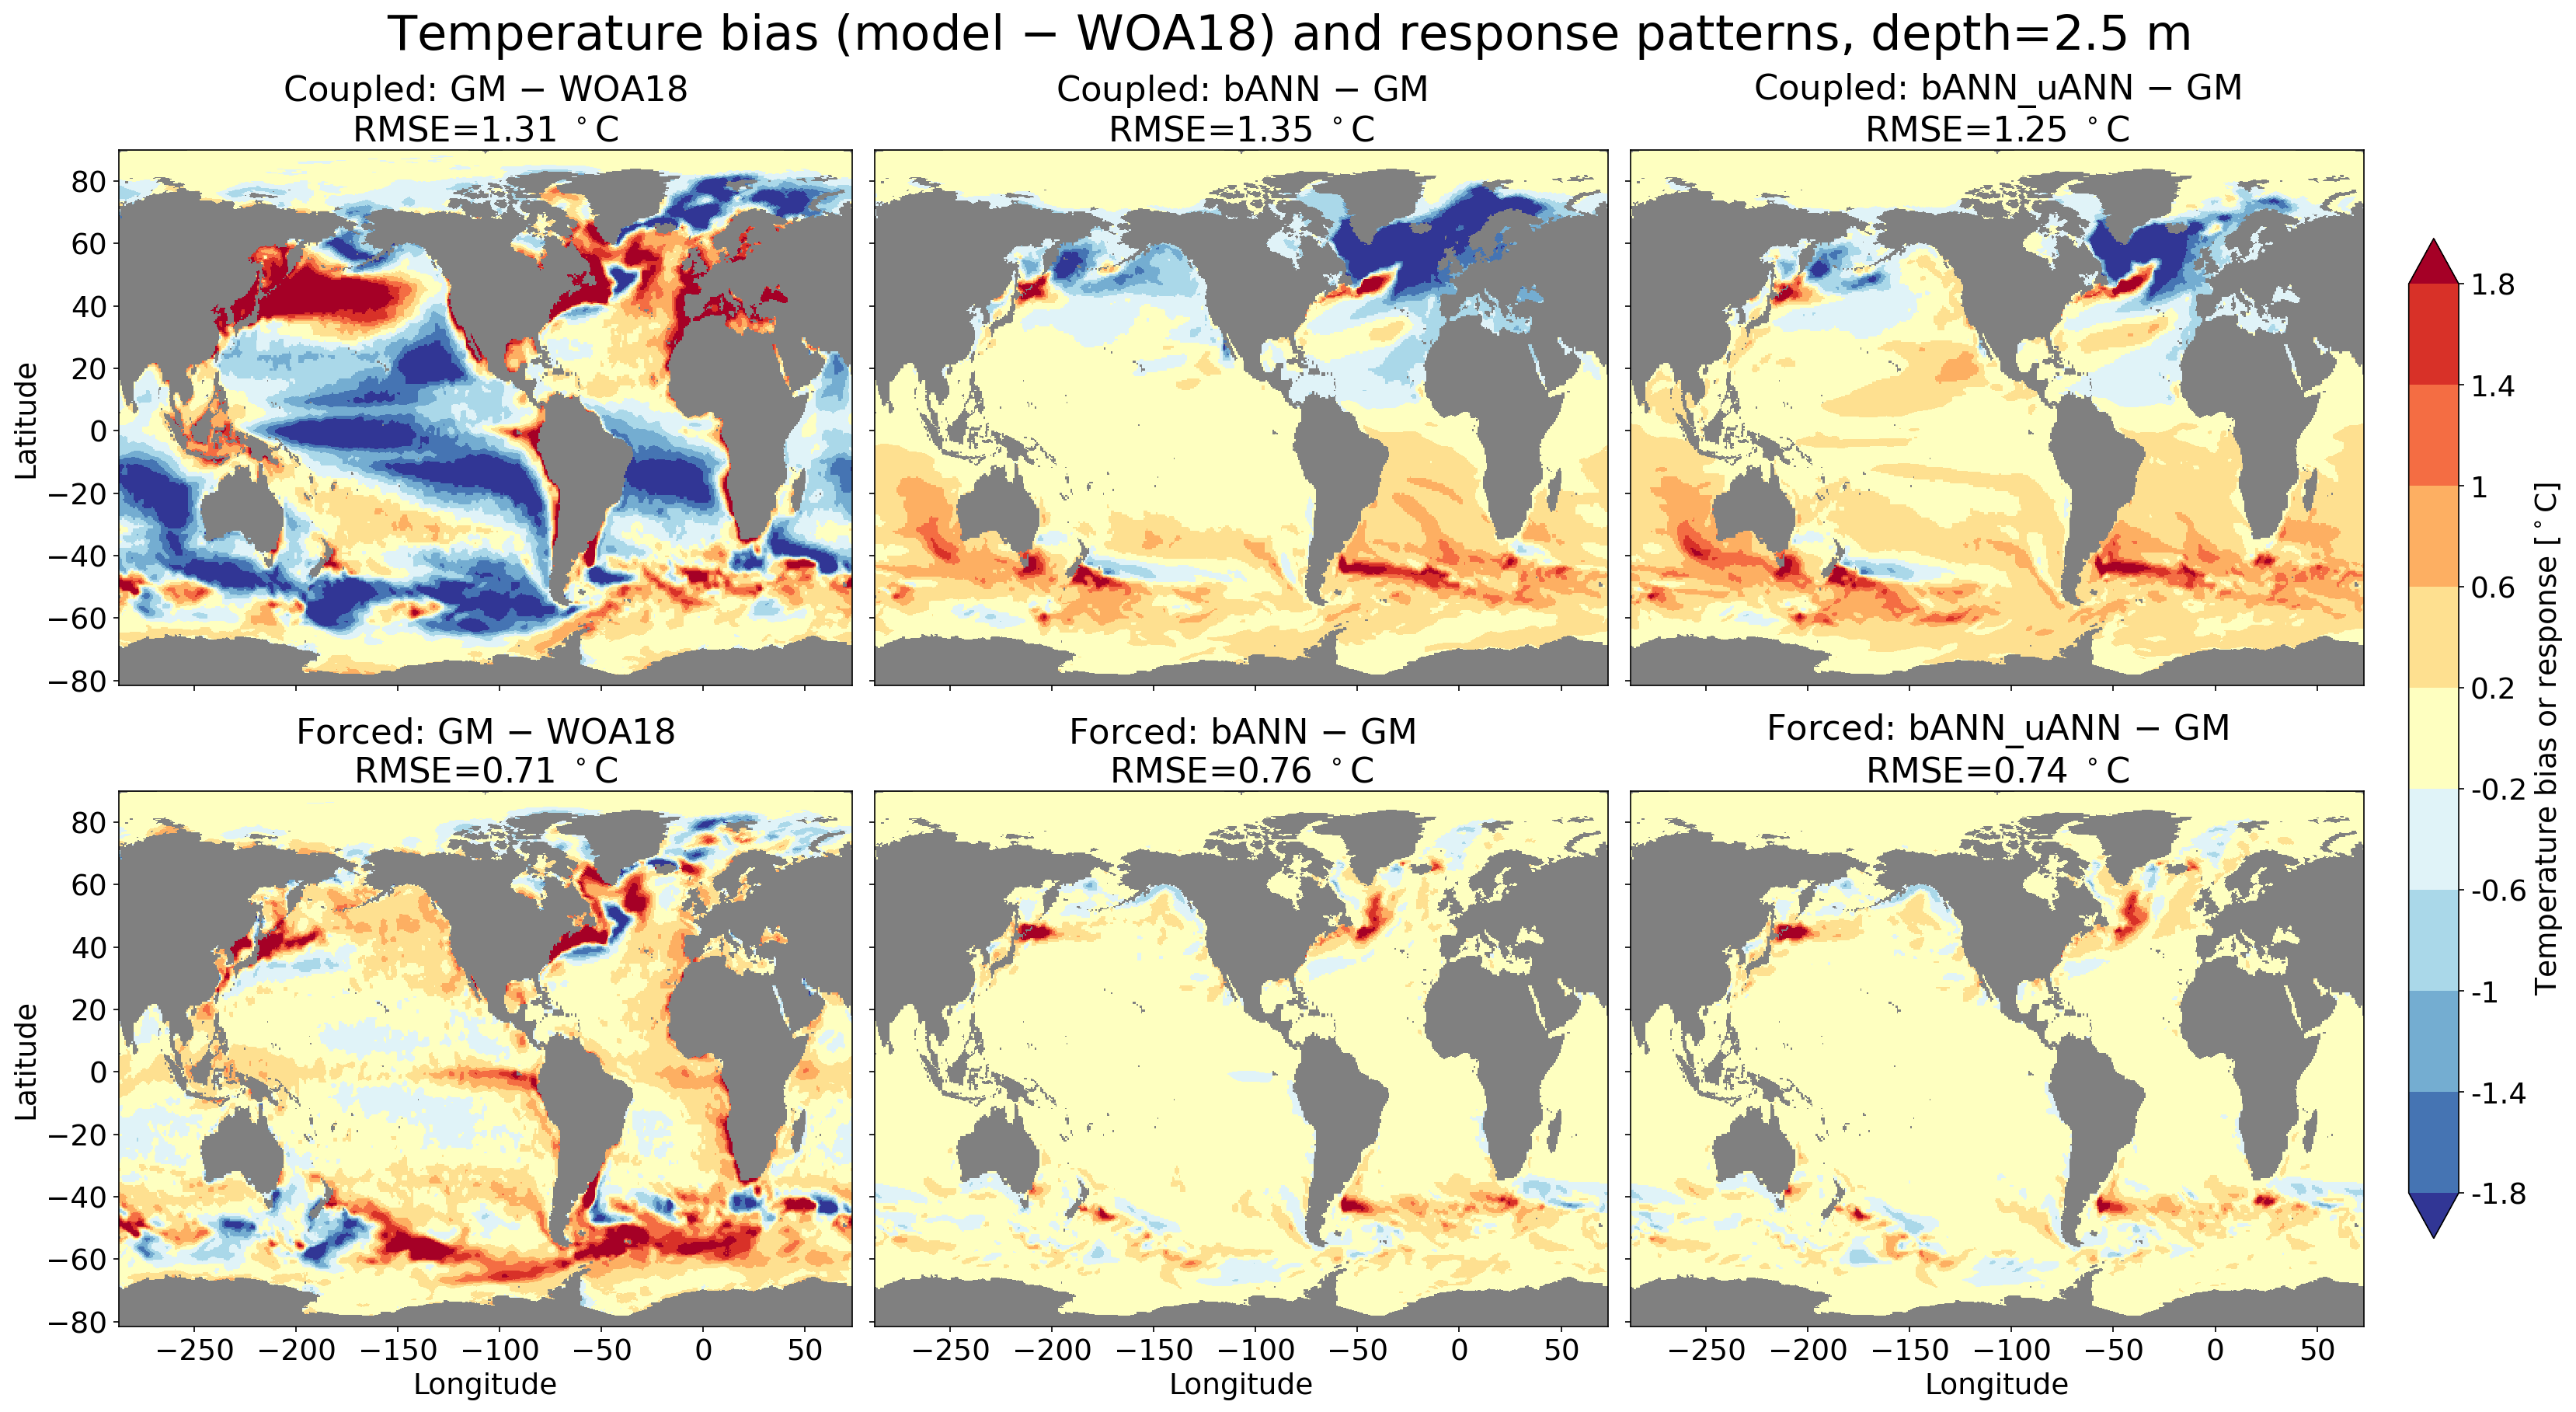

In [6]:
plot_thetao_bias_maps(2.5)   # surface (nearest z_l = 2.5 m)


# 3. Temperature bias (model - WOA18) at 250 m

Same diagnostic as section 2, but at ~250 m depth
(`z_l` selected by nearest value) instead of the surface.


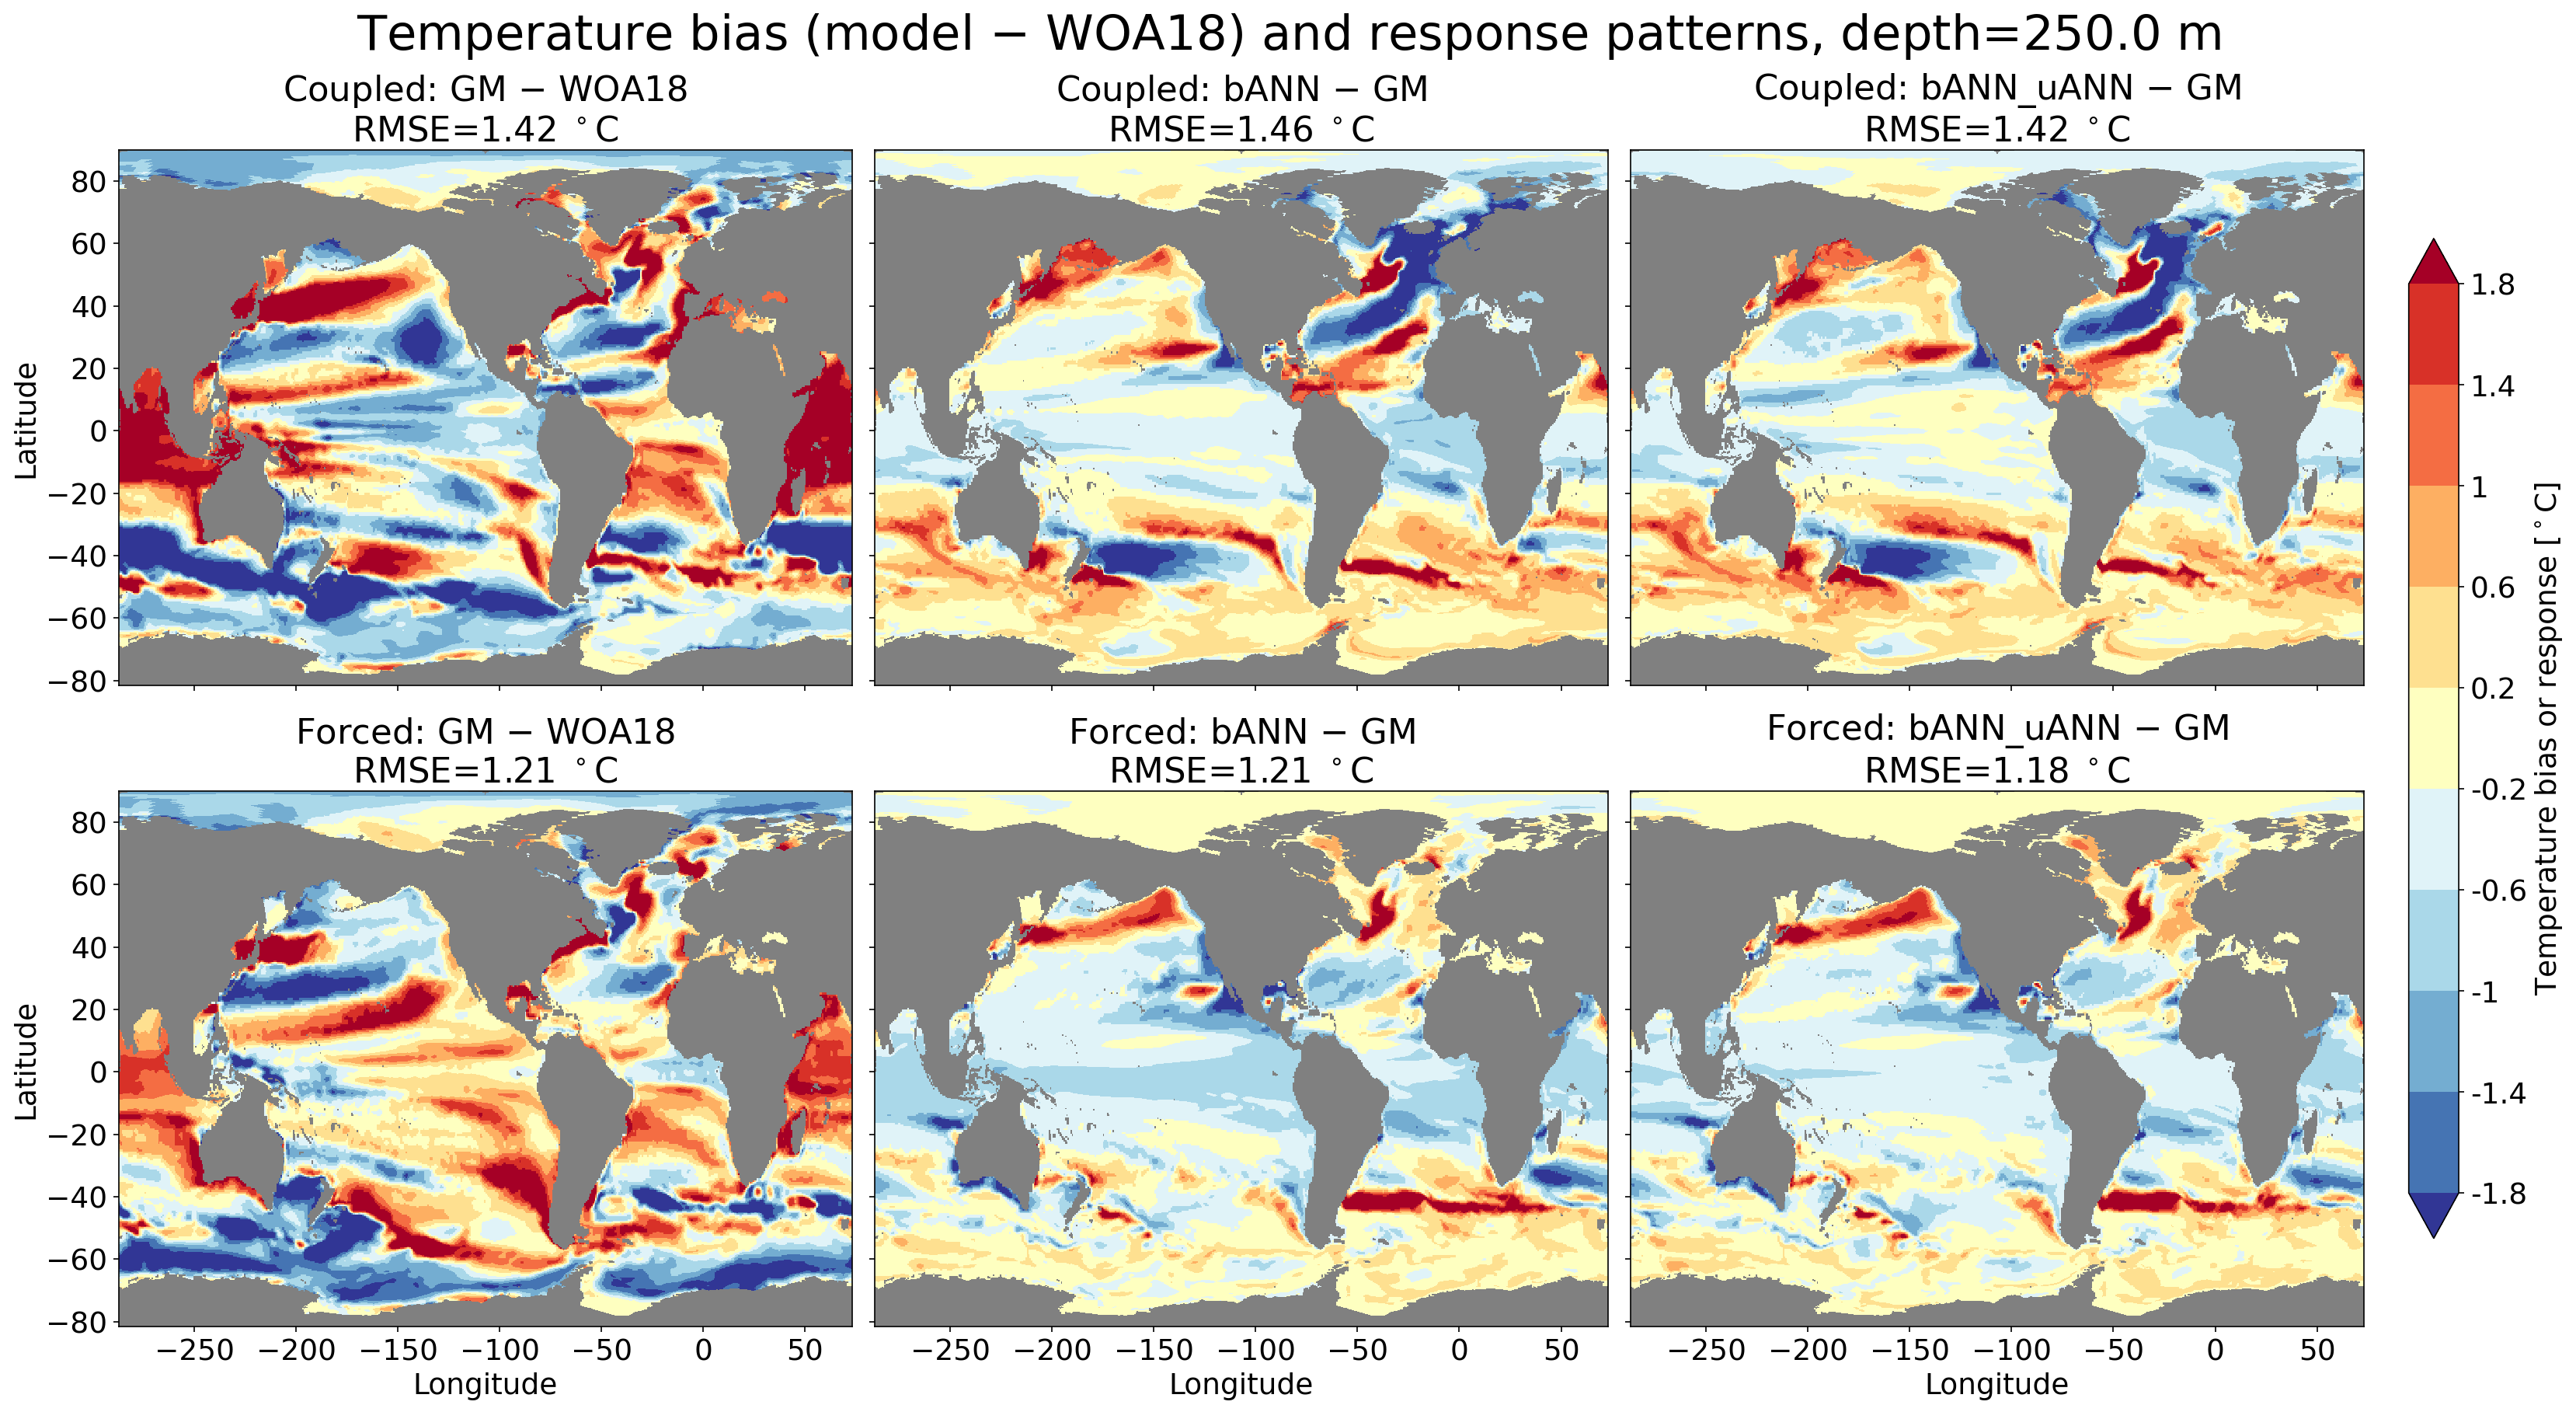

In [ ]:
# Same diagnostic as section 2, at ~250 m (nearest z_l level).
plot_thetao_bias_maps(250.0)

# 4. Salinity bias (model - WOA18)

Same diagnostic as section 2 but for practical salinity, read from the
precomputed `so_bias` field in each experiment's `*_so_time_mean.nc`
(`model - WOA18`, generated by `mom6_tools.TS_levels` against the WOA-2018
climatology). Shown at the surface level (nearest `z_l` = 2.5 m). RMSE is the
area-weighted RMS of the bias field (`mom6_tools.m6plot.myStats`).


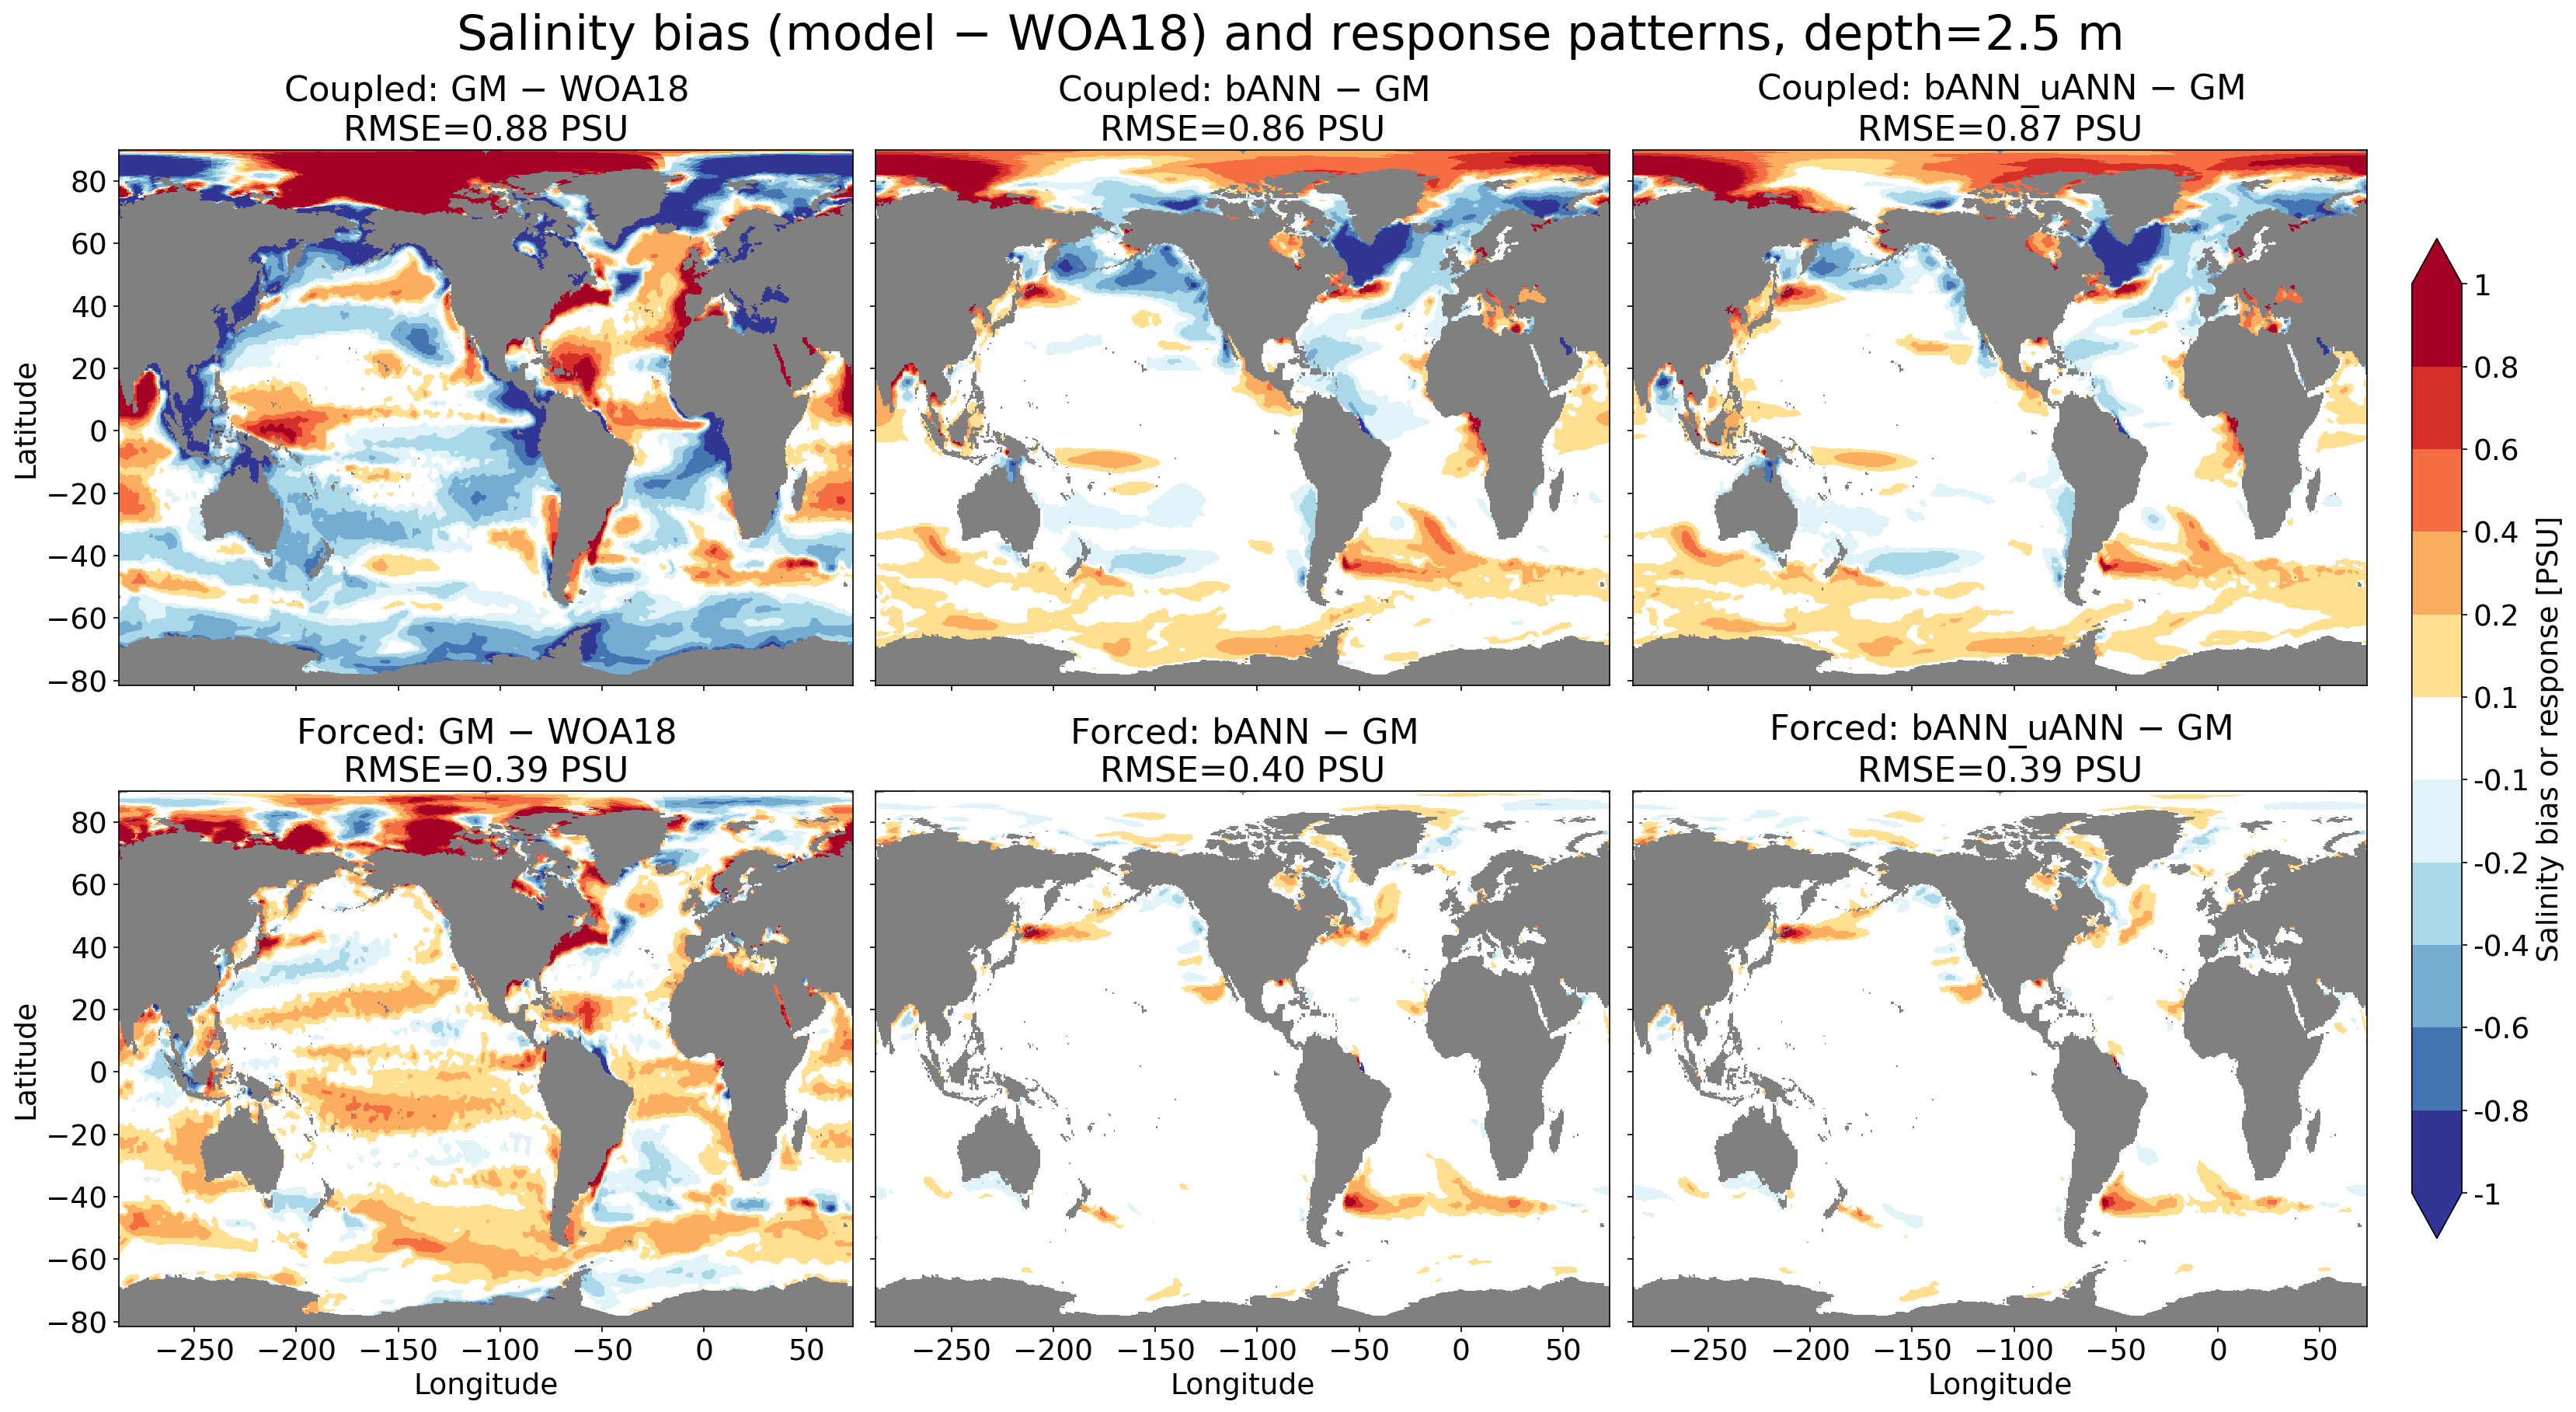

In [8]:
plot_so_bias_maps(2.5)   # surface (nearest z_l = 2.5 m)


# 5. Salinity bias (model - WOA18) at 250 m

Same diagnostic as section 4, but at ~250 m depth
(`z_l` selected by nearest value) instead of the surface.


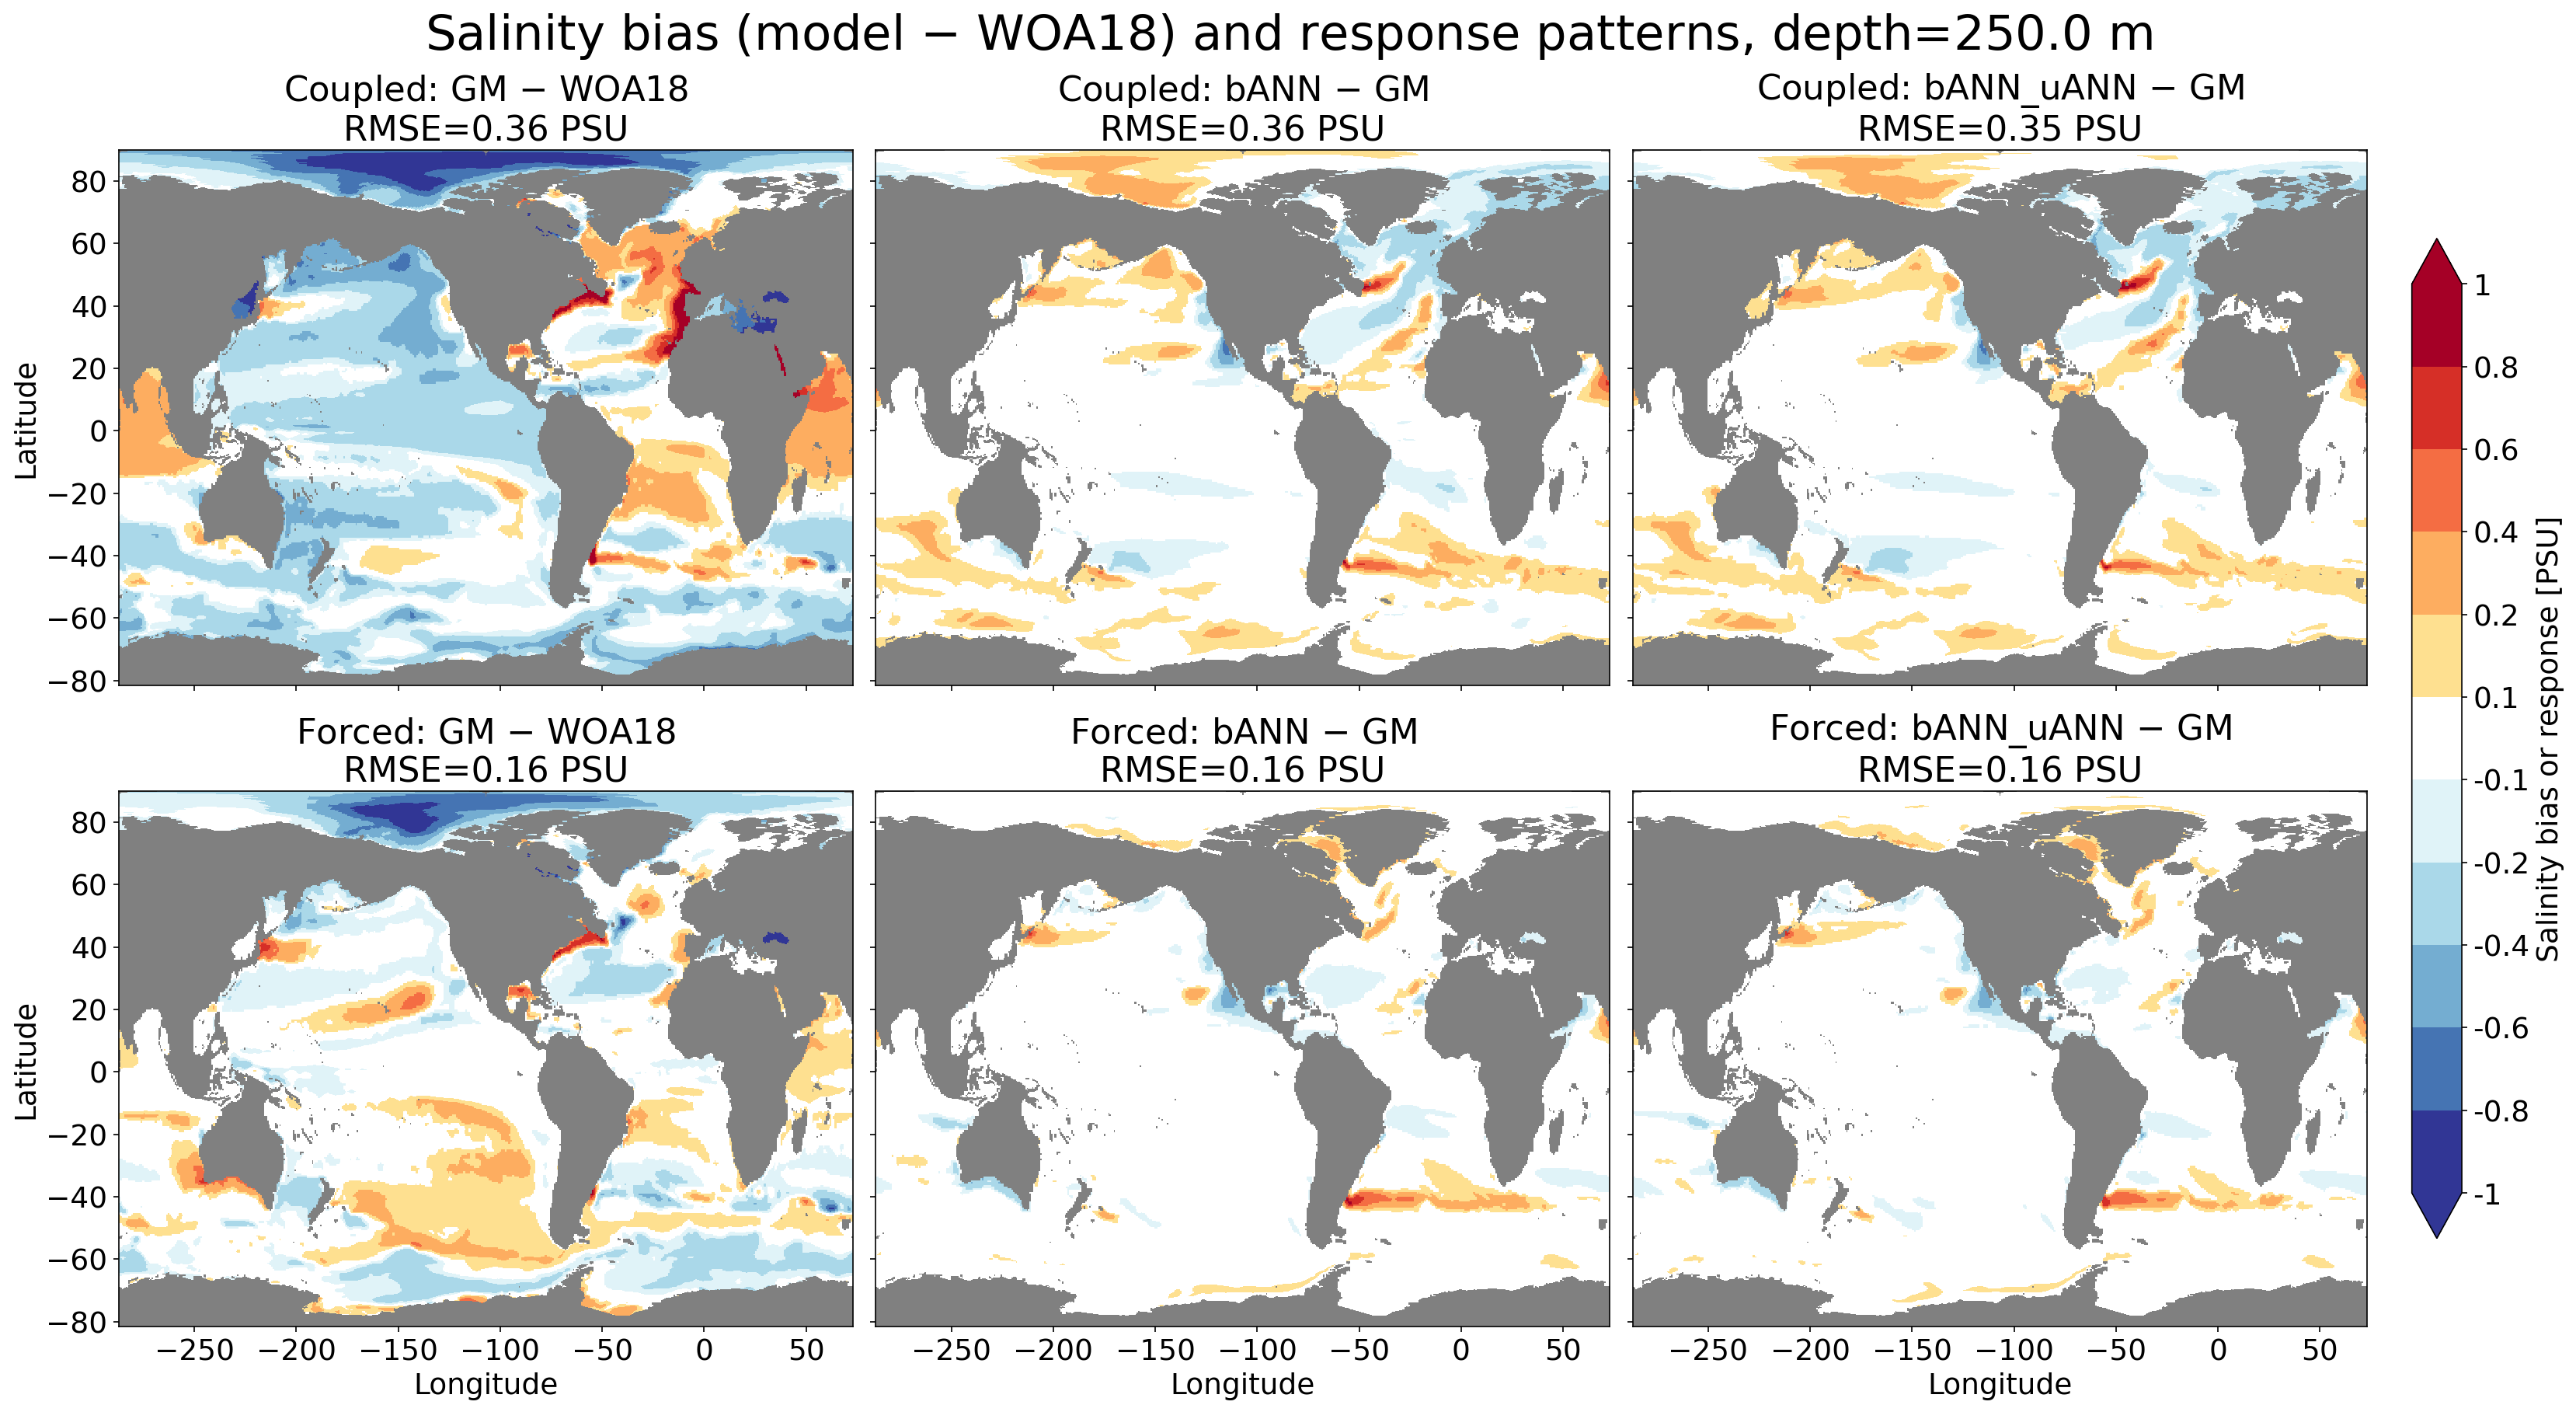

In [ ]:
# Same diagnostic as section 4, at ~250 m (nearest z_l level).
plot_so_bias_maps(250.0)


# 6. Zonally-averaged temperature bias (model $-$ WOA18) and response

Latitude–depth sections of the zonal-average temperature bias, mirroring
section 2 but averaged over longitude into 1° latitude bands via `zonal_ave`
(following `notebooks-development/compare_runs_coupled.ipynb`). Column 1 shows
the GM bias (`model $-$ WOA18`); columns 2–3 show each experiment's response
(`exp $-$ GM`). RMSE is always the RMS of the zonally-averaged `model $-$ WOA18`
bias. The depth axis is piecewise-linear (0–200, 200–1000, 1000–5500 m, each
band spanning one third of the height).


In [17]:
# --- Zonally-averaged bias / response sections (latitude vs depth) ---
# Reuses the precomputed model - WOA18 bias fields; the zonal average and
# depth-axis styling follow notebooks-development/compare_runs_coupled.ipynb.

def zonal_ave(array, geolat):
    """Bin a field into 1-degree latitude bands using true geolat (tripolar-safe)."""
    bins = array.yh.values
    bins = (bins[:-1] + bins[1:]) / 2
    return array.groupby_bins(geolat, bins=bins).mean()

# Piecewise-linear depth axis: 0-200, 200-1000, 1000-5500 m each get 1/3 of the height
d_edges = [0, 200, 1000, 5500]

def _depth_forward(d):
    d = np.asarray(d, dtype=float)
    return np.where(d <= d_edges[1], (d - d_edges[0]) / (d_edges[1] - d_edges[0]) / 3,
           np.where(d <= d_edges[2], 1 / 3 + (d - d_edges[1]) / (d_edges[2] - d_edges[1]) / 3,
                    2 / 3 + (d - d_edges[2]) / (d_edges[3] - d_edges[2]) / 3))

def _depth_inverse(y):
    y = np.asarray(y, dtype=float)
    return np.where(y <= 1 / 3, d_edges[0] + y * 3 * (d_edges[1] - d_edges[0]),
           np.where(y <= 2 / 3, d_edges[1] + (y - 1 / 3) * 3 * (d_edges[2] - d_edges[1]),
                    d_edges[2] + (y - 2 / 3) * 3 * (d_edges[3] - d_edges[2])))

def plot_bias_zonal(get_bias, diff_levels, cmap, quantity, unit, cbar_label,
                    rmse_fmt='.2f'):
    """2x3 latitude-depth zonal-average bias (model - WOA18) and exp - GM response."""
    fig, axes = plt.subplots(2, 3, figsize=(22, 12), dpi=150,
                             sharex=True, sharey=True, constrained_layout=True)
    im = None
    for row, (regime, names) in enumerate([('Coupled', coupled_row),
                                           ('Forced', forced_row)]):
        geolat = exps[names[0]].grd.geolat
        gm_bias = get_bias(exps[names[0]])            # (z_l, yh, xh) = model - WOA18
        for col, name in enumerate(names):
            ax = axes[row, col]
            bias = get_bias(exps[name])
            bias_za = zonal_ave(bias, geolat)
            if col == 0:
                field_za = bias_za
                title = f'{regime}: {LABELS[name]} ' + r'$-$' + ' WOA18'
            else:
                field_za = zonal_ave(bias - gm_bias, geolat)
                title = f'{regime}: {LABELS[name]} ' + r'$-$' + ' GM'
            rmse = float(np.sqrt((bias_za ** 2).mean()))   # RMSE always vs WOA18
            im = field_za.plot.contourf(ax=ax, levels=diff_levels, cmap=cmap,
                                        extend='both', add_colorbar=False)
            ax.set_title(f'{title}\nRMSE={rmse:{rmse_fmt}} {unit}')
            ax.set_yscale('function', functions=(_depth_forward, _depth_inverse))
            ax.set_ylim(d_edges[3], d_edges[0])
            ax.set_yticks([0, 100, 200, 500, 1000, 2000, 3000, 4000, 5000, 5500])
            for d in (d_edges[1], d_edges[2]):
                ax.axhline(d, color='0.5', lw=0.8, ls='--')
            ax.set_xlim([-80, 80])
            ax.set_xlabel('Latitude' if row == 1 else '')
            ax.set_ylabel('Depth [m]' if col == 0 else '')
            ax.set_facecolor('gray')
    cbar = fig.colorbar(im, ax=axes, label=cbar_label, extend='both',
                        ticks=diff_levels, spacing='uniform',
                        shrink=0.85, pad=0.02)
    cbar.ax.set_yticklabels([f'{b:g}' for b in diff_levels])
    fig.suptitle(f'Zonally-averaged {quantity.lower()} bias (model $-$ WOA18) '
                 'and response patterns', fontsize=30)
    plt.show()

# Temperature zonal levels: same continuous colorbar as the maps, range
# reduced 2x (+/-0.9 degC); 0.0 is not a level boundary.
TZONAL_LEVELS = np.arange(-0.9, 0.91, 0.2)

def plot_thetao_zonal():
    plot_bias_zonal(lambda e: e.thetao().thetao_bias, TZONAL_LEVELS, 'RdYlBu_r',
                    'Temperature', r'$^\circ$C', r'Temperature bias [$^\circ$C]')

# Salinity zonal levels: reuse the maps' neutral-band colorbar (S_CMAP) with the
# range reduced 2x (+/-0.5 PSU) and 0.0 excluded (neutral [-0.05, 0.05] bin).
SZONAL_LEVELS = np.array([-0.5, -0.4, -0.3, -0.2, -0.1, -0.05,
                          0.05, 0.1, 0.2, 0.3, 0.4, 0.5])

def plot_so_zonal():
    plot_bias_zonal(lambda e: e.so().so_bias, SZONAL_LEVELS, S_CMAP,
                    'Salinity', 'PSU', 'Salinity bias [PSU]')

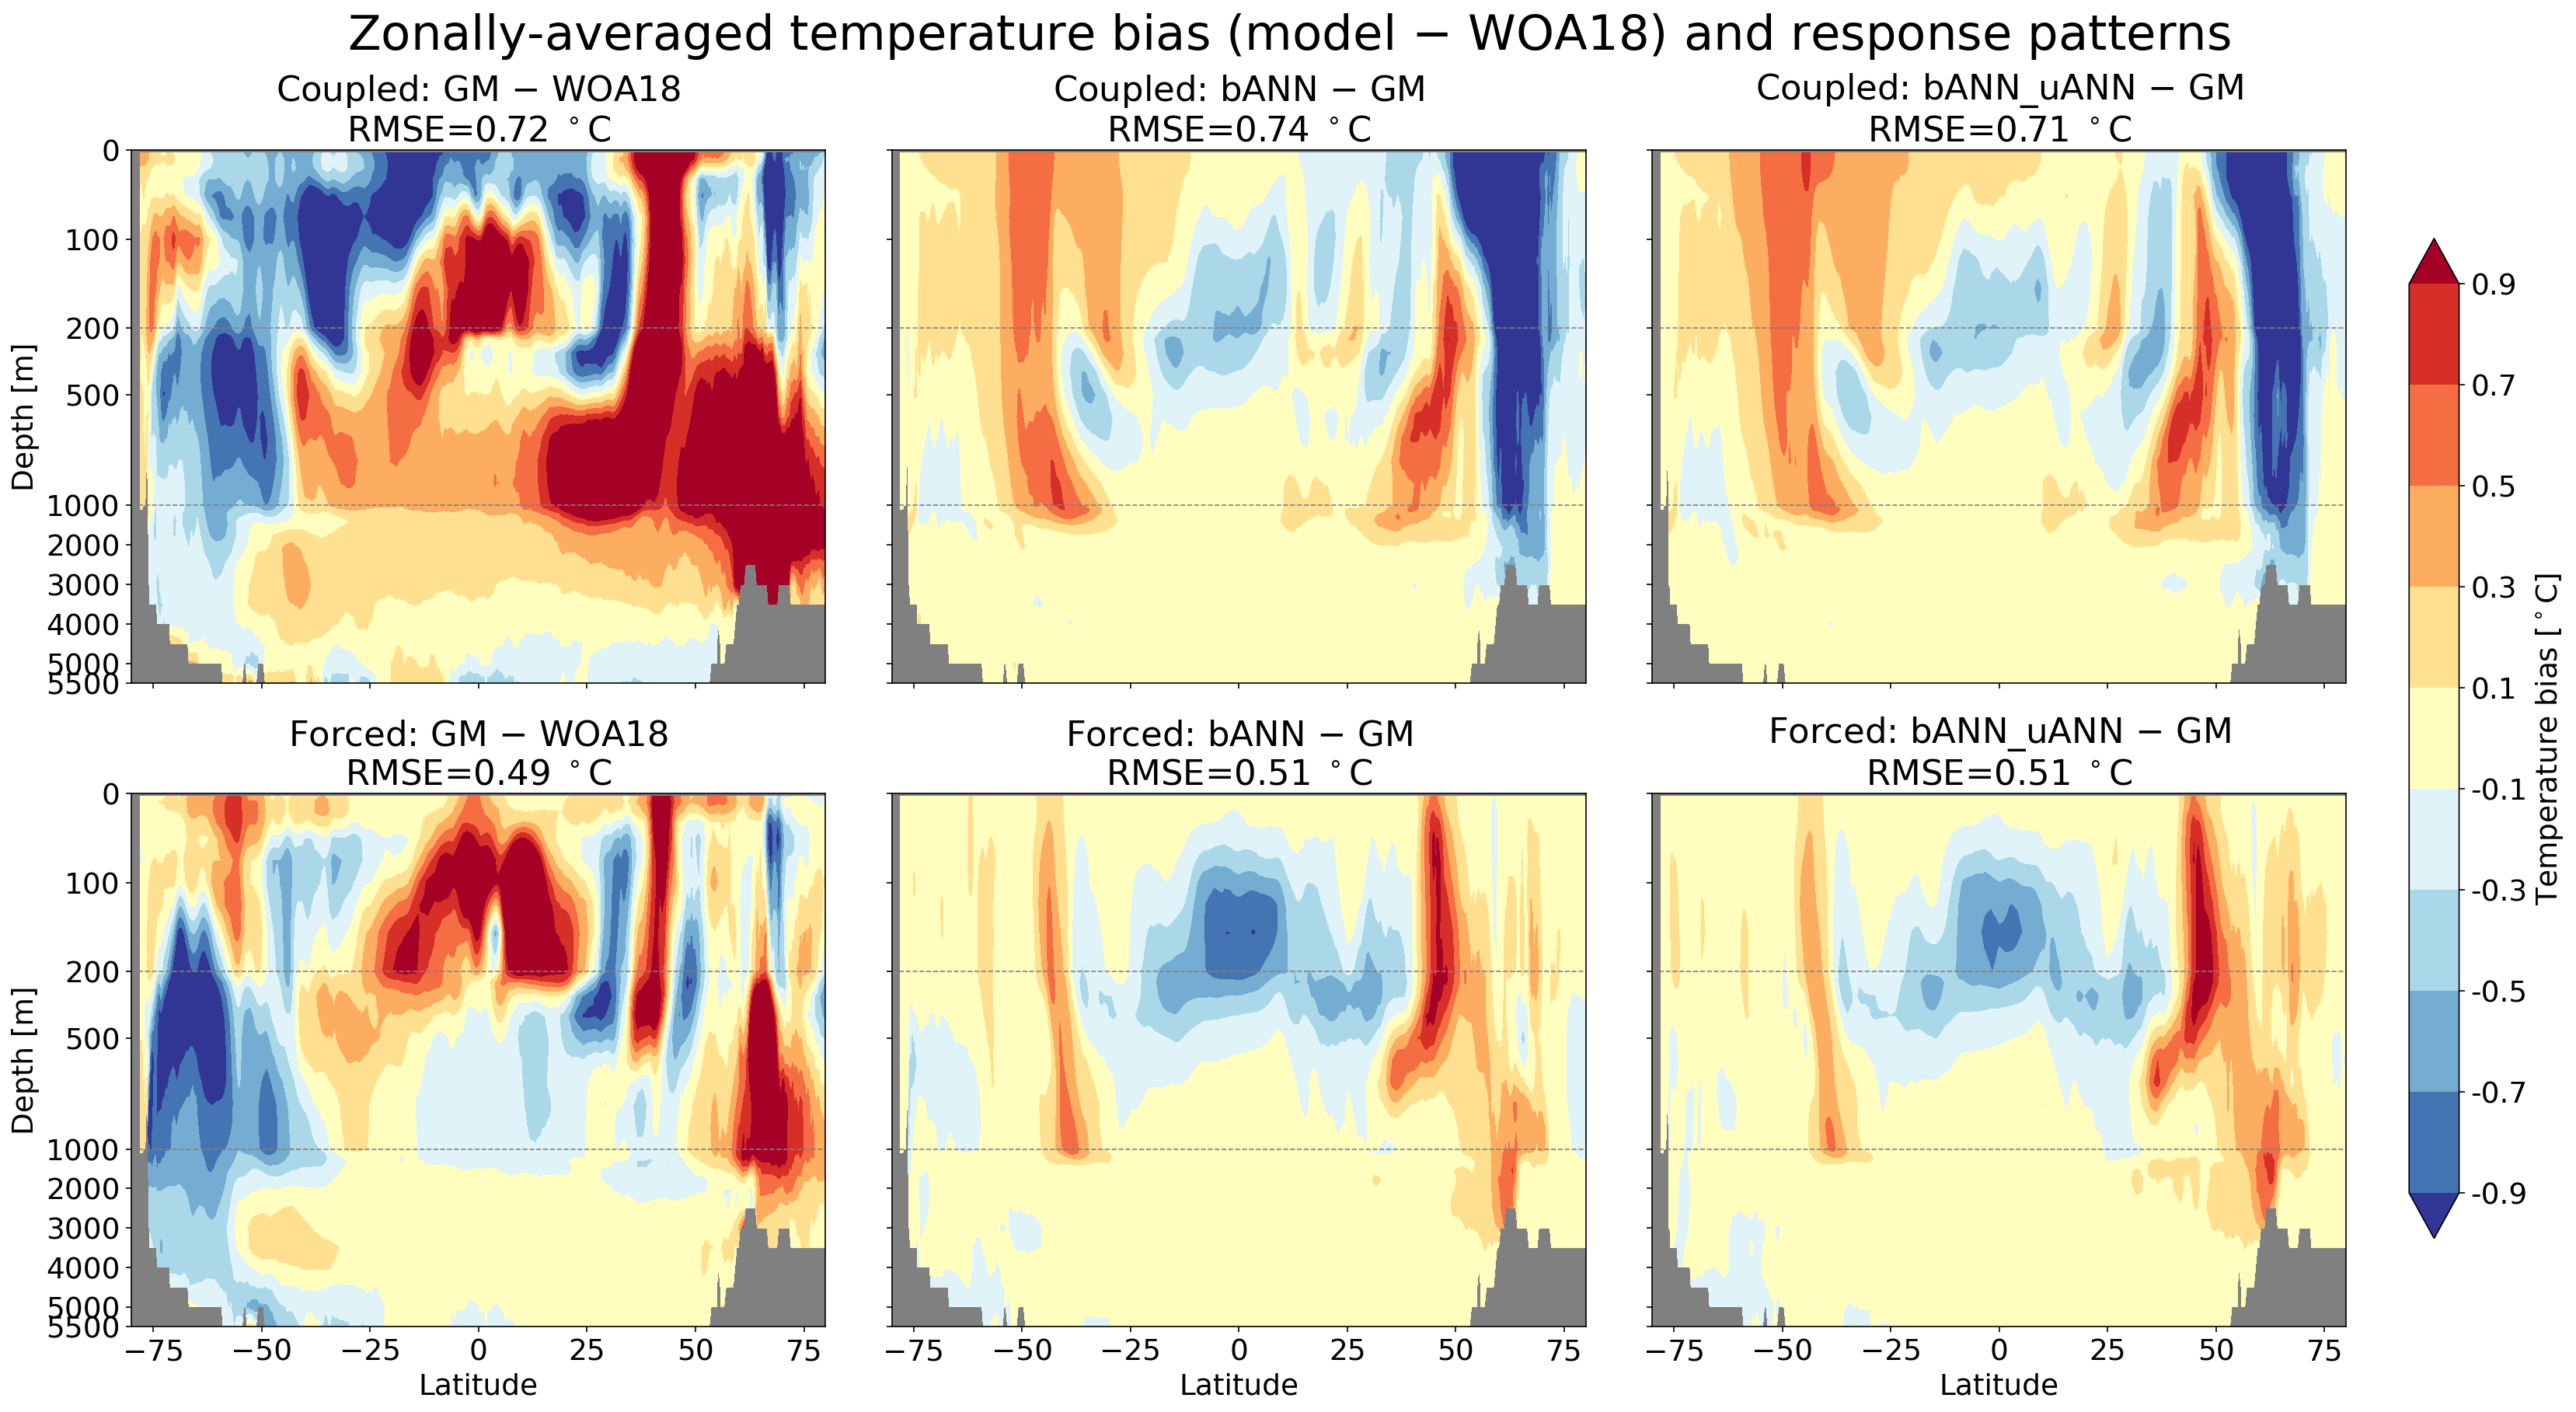

In [11]:
plot_thetao_zonal()

# 7. Zonally-averaged salinity bias (model $-$ WOA18) and response

Same latitude–depth zonal-average diagnostic as section 6, but for practical
salinity (`so_bias`). Column 1 shows the GM bias (`model $-$ WOA18`); columns 2–3
show each experiment's response (`exp $-$ GM`). RMSE is always the RMS of the
zonally-averaged `model $-$ WOA18` bias.


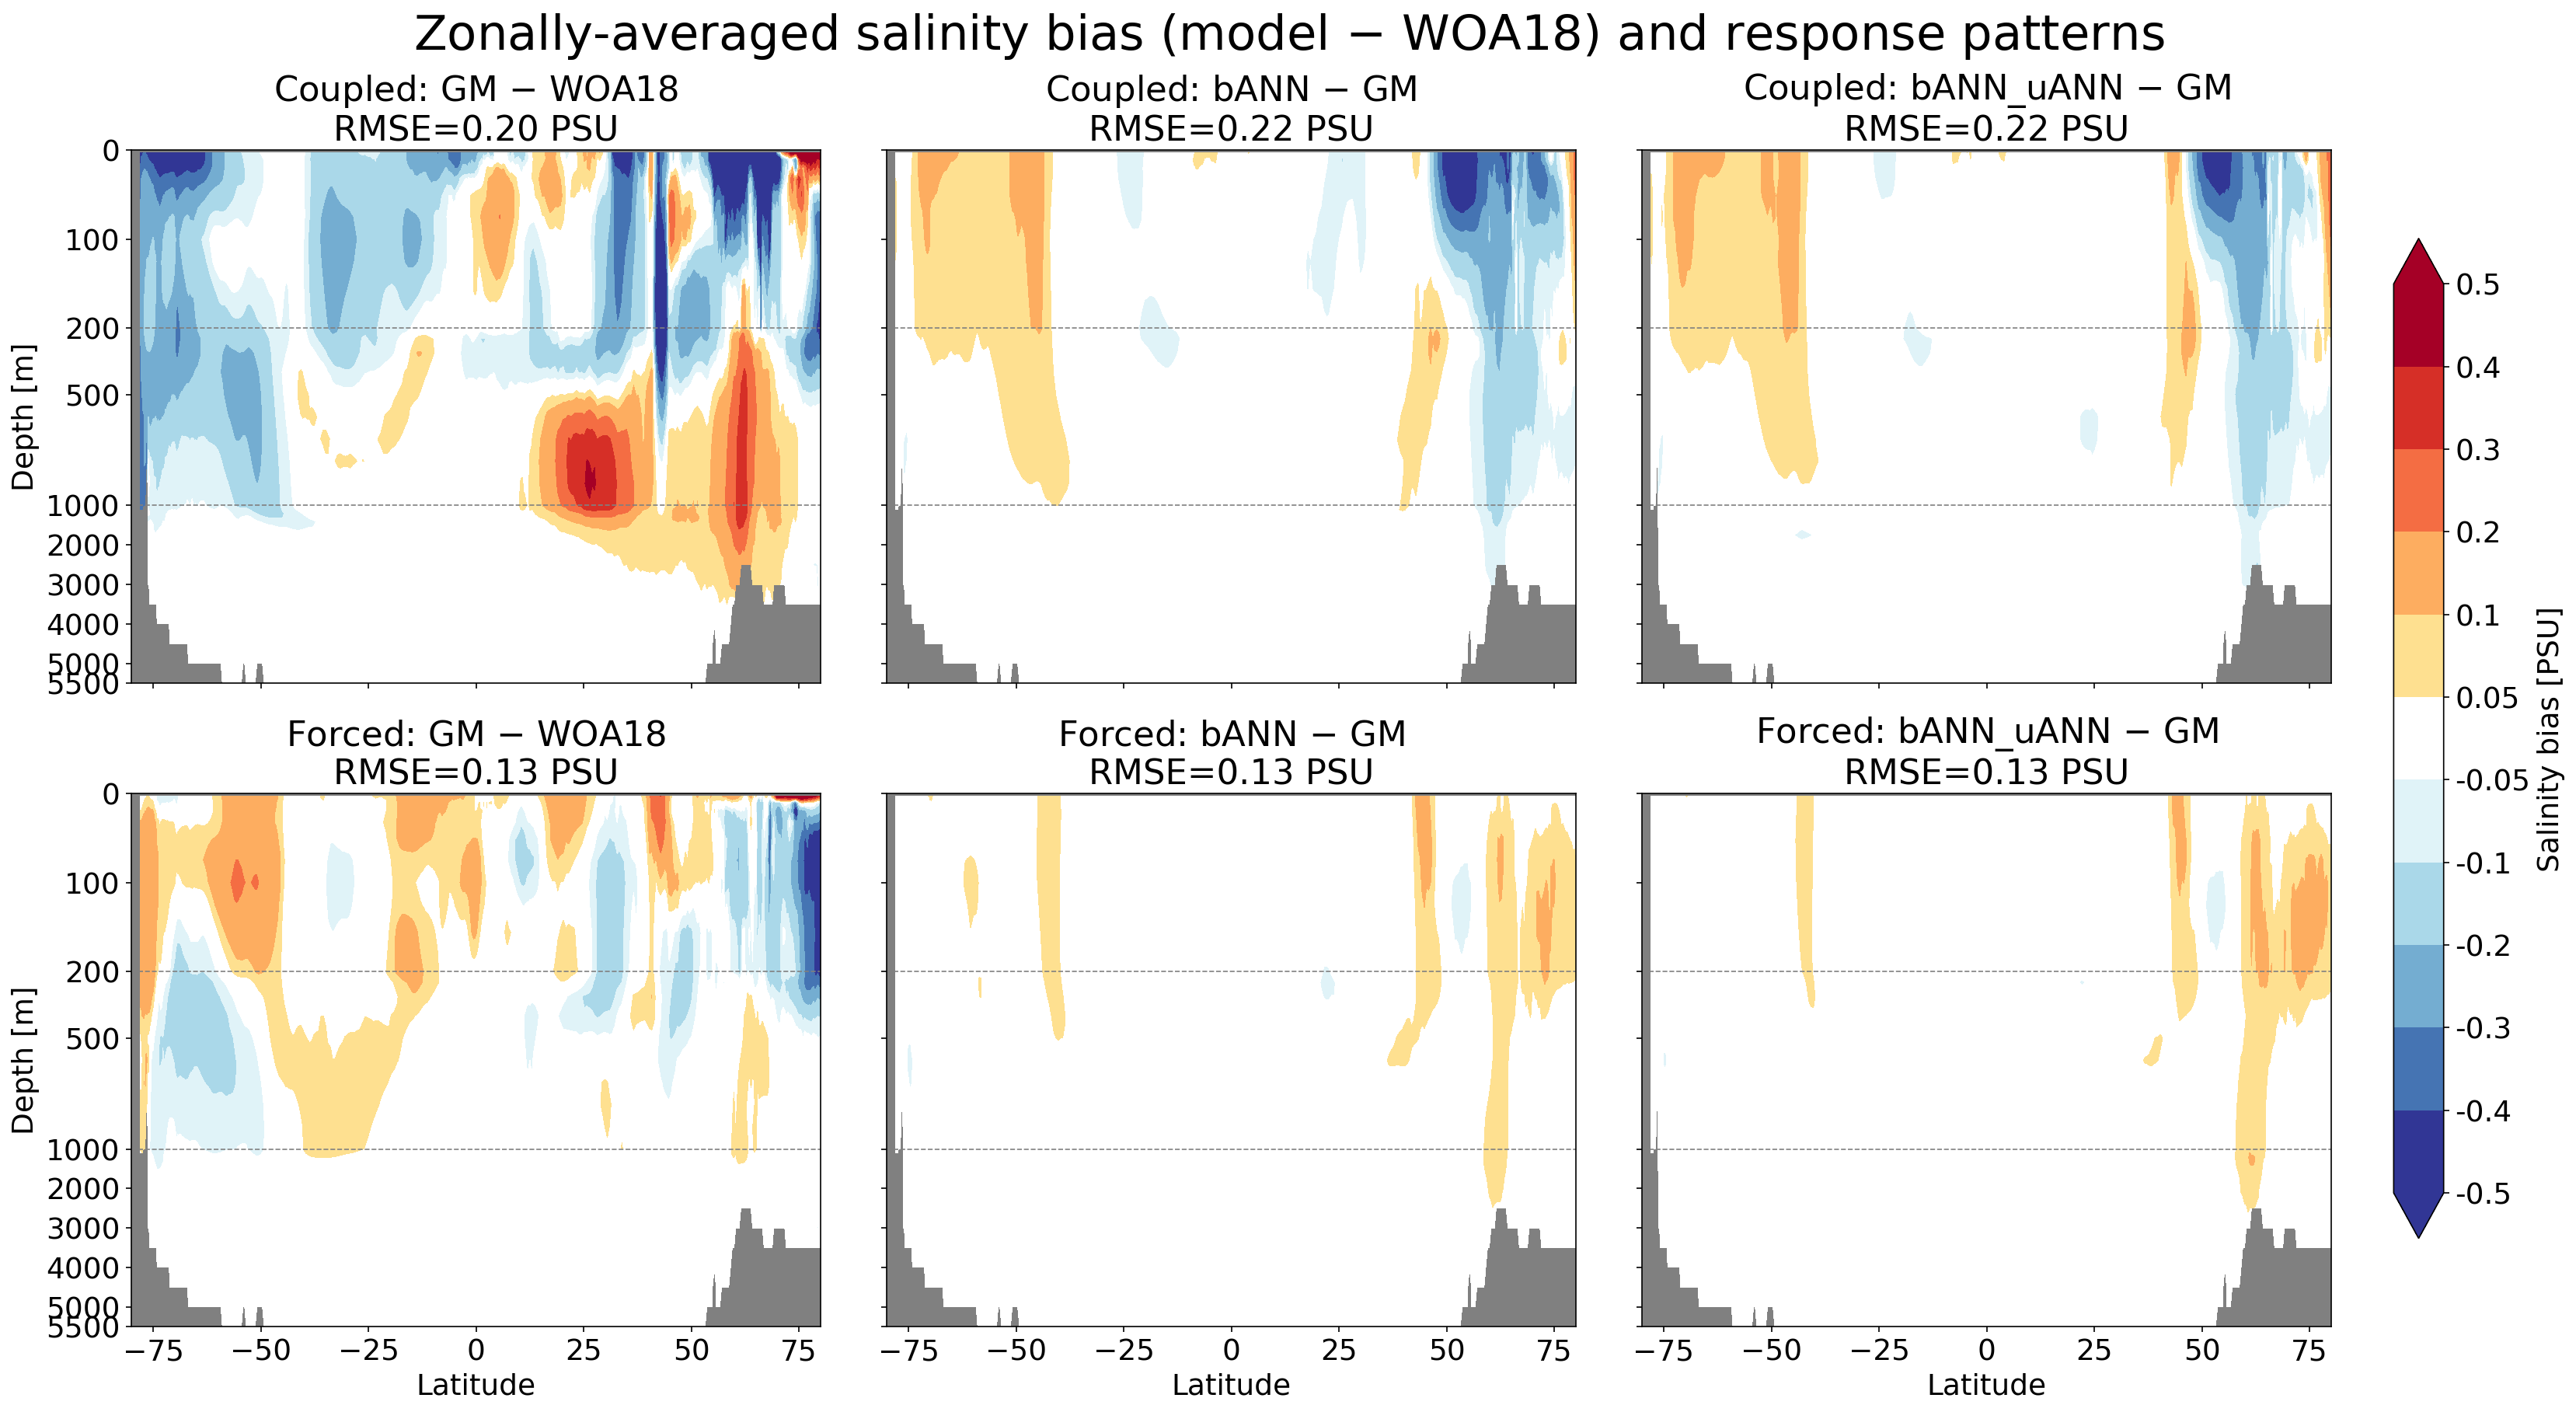

In [12]:
plot_so_zonal()

# 8. Zonally-averaged potential density ($\sigma_2$) bias and response

Same latitude–depth zonal-average diagnostic as Sections 6–7, but for potential
density $\sigma_2$, computed as in Section 9 (`gsw.sigma2`, with WOA-2018
$\sigma_2$ recovered as model $-$ bias). Column 1 shows the GM bias
(`model $-$ WOA18`); columns 2–3 show each experiment's response (`exp $-$ GM`).
RMSE is always the RMS of the zonally-averaged `model $-$ WOA18` bias. Land is
shown in gray.

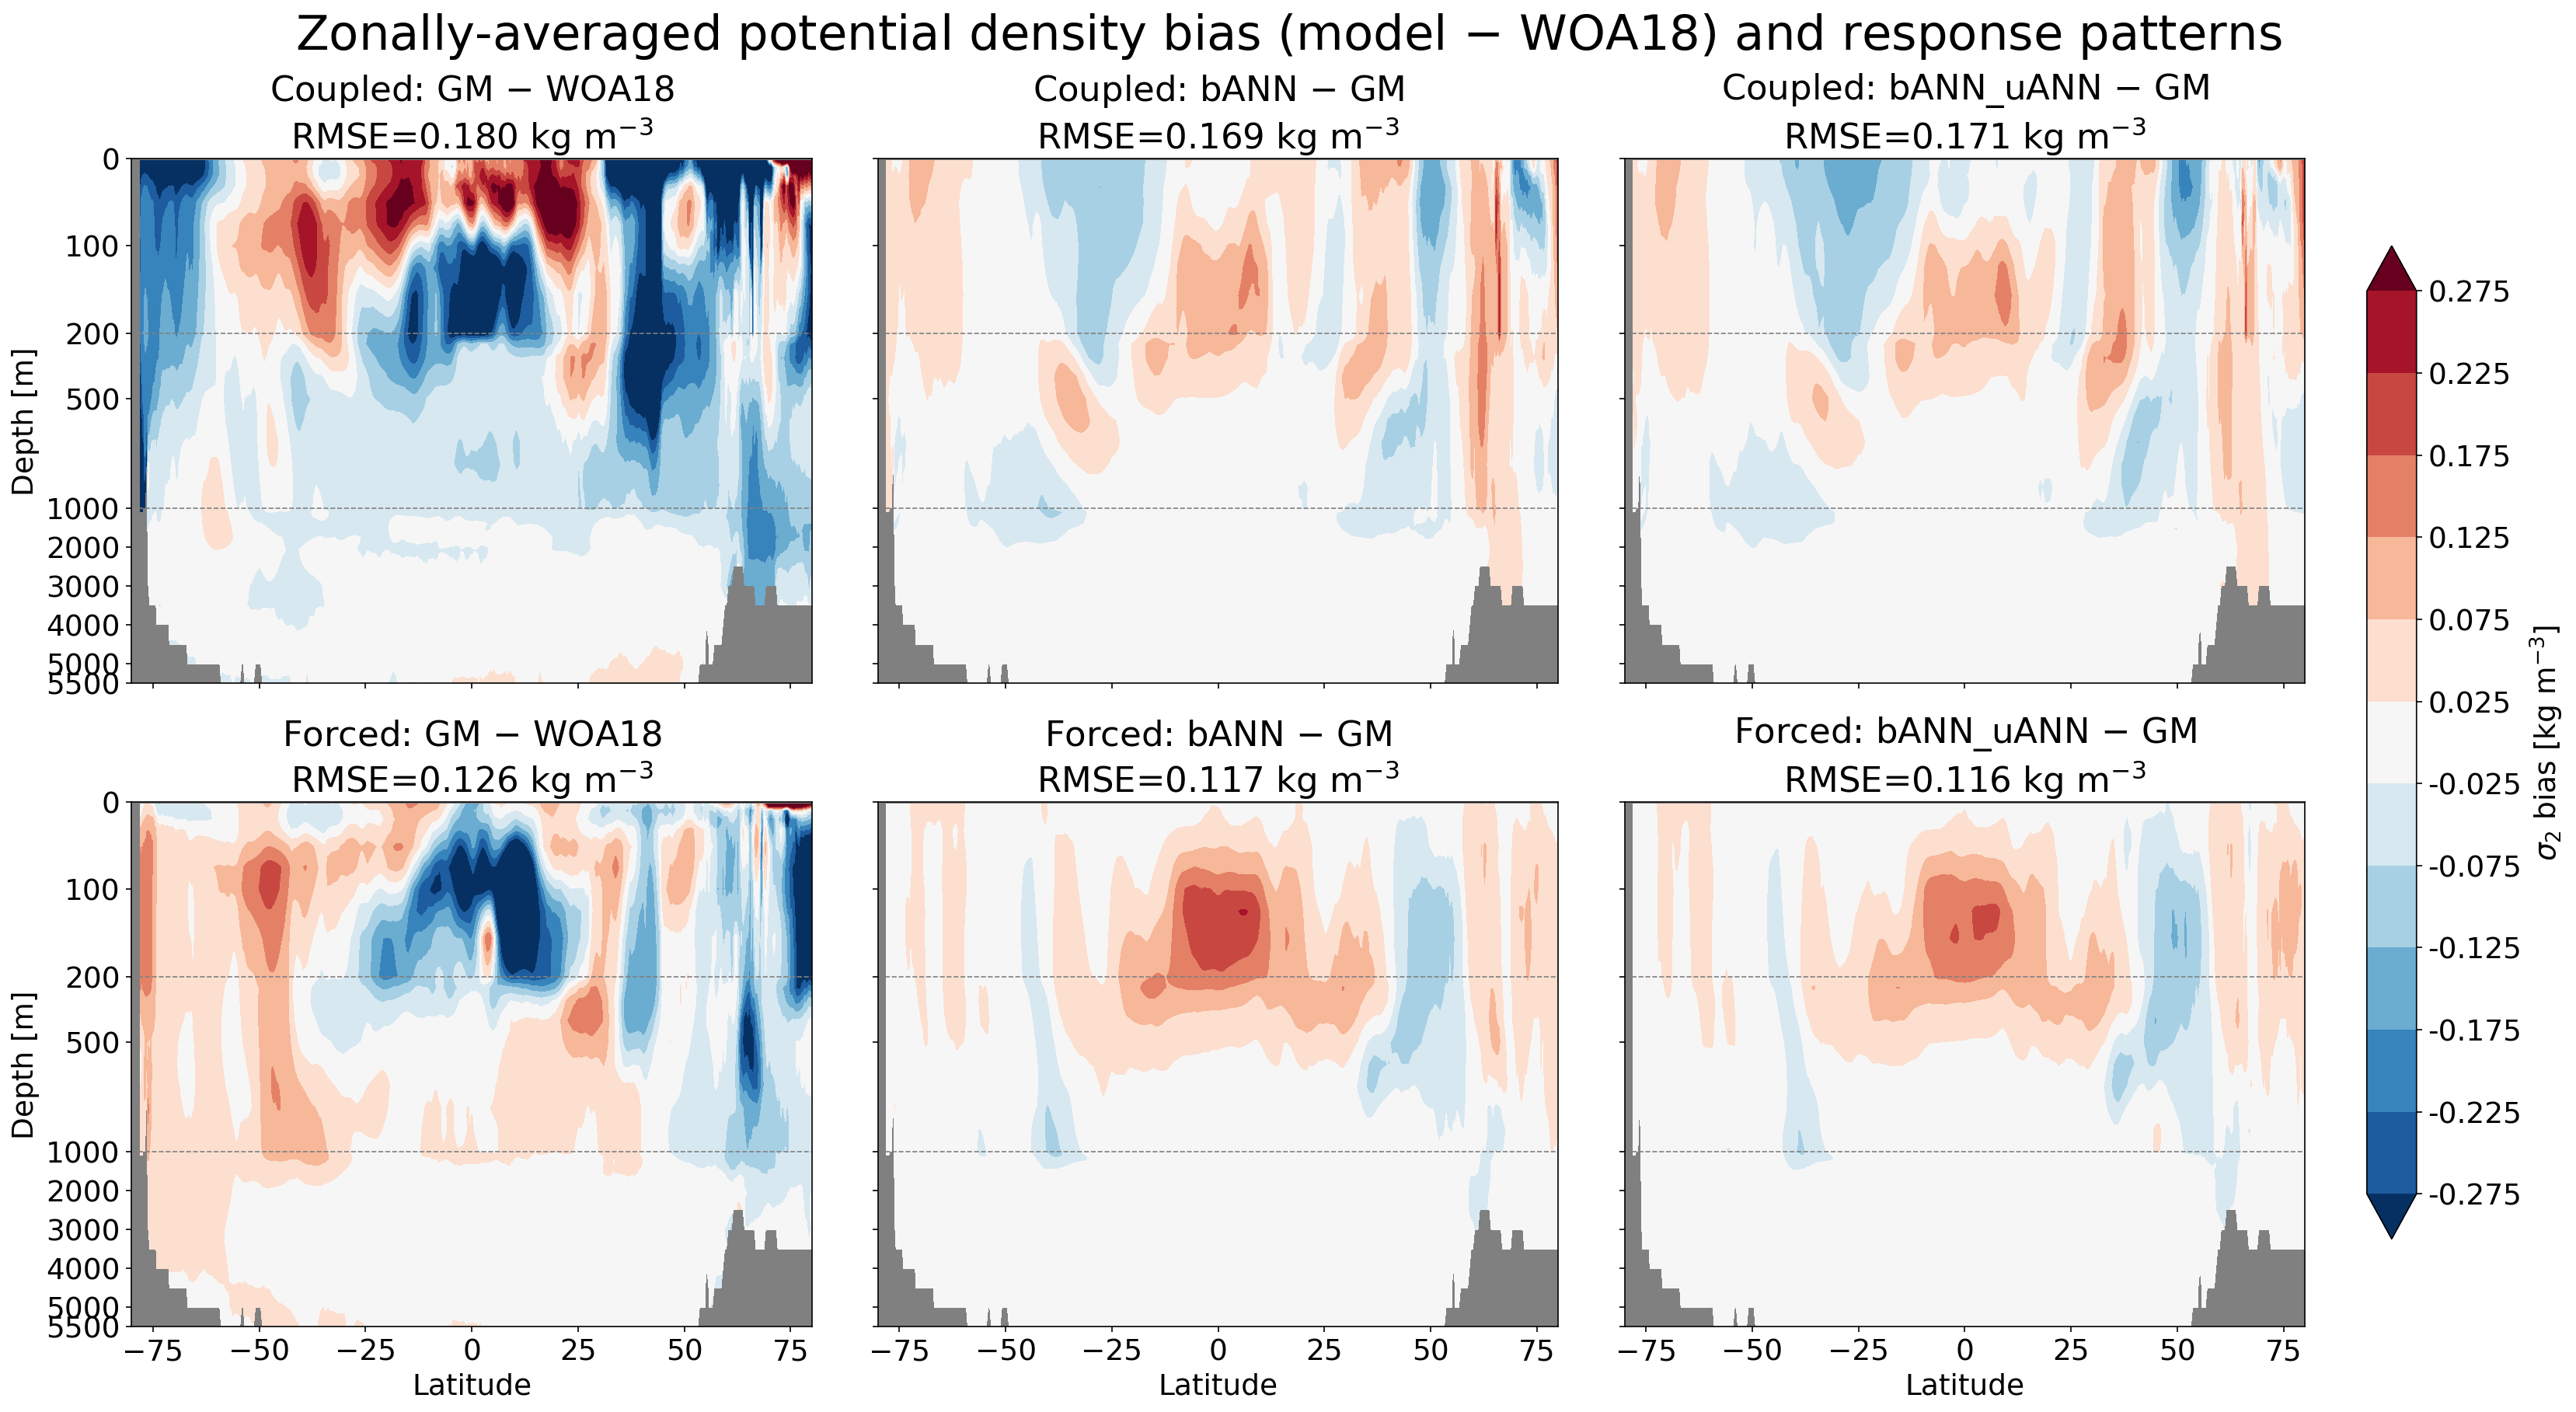

In [ ]:
# --- Section 9: zonally-averaged potential density (sigma2) bias and response ---
# sigma2 computed as in Section 9 (gsw.sigma2); bias = model sigma2 - WOA18 sigma2.
# Reuses plot_bias_zonal (gray land, piecewise depth axis) and obs_sigma2 from above.
DZONAL_LEVELS = np.arange(-0.275, 0.28, 0.05)  # shifted by half a step

def plot_sigma2_zonal():
    plot_bias_zonal(lambda e: e.sigma2() - obs_sigma2(e), DZONAL_LEVELS, 'RdBu_r',
                    'Potential density', r'kg m$^{-3}$',
                    r'$\sigma_2$ bias [kg m$^{-3}$]', rmse_fmt='.3f')

plot_sigma2_zonal()

## 9. Zonal-mean meridional isopycnal slope

Following Danabasoglu & Marshall (2007, Fig. 4), we plot the time- and zonal-mean
meridional isopycnal slope of $\sigma_2$ potential density. To avoid the blow-up
where stratification is weak, we use the regularized (bounded) definition

$$S_y = \frac{\partial\rho/\partial y}{\sqrt{(\partial\rho/\partial y)^2 + (\partial\rho/\partial z)^2}}\,,$$

which equals the true slope $-\partial_y\rho/\partial_z\rho$ for small slopes but stays in
$[-1, 1]$. For each field we (1) zonally average the density into 1° latitude bands,
(2) coarse-grain in latitude, and (3) compute the slope. Observed $\sigma_2$ is
recovered as model $-$ bias (WOA-2018). Columns:

- **Left** — observed slope $S_y$, with observed $\sigma_2$ isopycnals overlaid.
- **Middle** — GM bias in slope (GM $-$ WOA18).
- **Right** — bANN response (bANN $-$ GM).

Rows are the coupled and forced regimes; all panels share the same
double-logarithmic color scale.

In [13]:
# --- Zonal-mean meridional isopycnal slope (Danabasoglu & Marshall 2007, Fig. 4) ---
# Columns: (1) WOA18 slope + WOA18 sigma2 contours, (2) GM bias (GM - WOA18), (3) response (bANN - GM).
# Order per field: (1) zonal-average density, (2) meridional coarse-grain, (3) slope.
# Regularized (non-exploding) slope:  Sy = rho_y / sqrt(rho_y^2 + rho_z^2)
import gsw
R_EARTH = 6371.0e3  # m
SLOPE_COARSEN = 4   # coarse-grain factor in the latitude direction (1 = off)

def _grad_masked(field, coord, axis):
    """np.gradient along `axis`, but any point whose 3-point stencil touches a
    NaN (land / ocean boundary) is set to NaN so slopes are not contaminated by
    one-sided differences across the boundary."""
    g = np.gradient(field, coord, axis=axis)
    finite = np.isfinite(field)
    valid = finite & np.roll(finite, 1, axis=axis) & np.roll(finite, -1, axis=axis)
    edge = [slice(None)] * field.ndim
    edge[axis] = 0
    valid[tuple(edge)] = False
    edge[axis] = -1
    valid[tuple(edge)] = False
    return np.where(valid, g, np.nan)

def obs_sigma2(exp):
    """Observational sigma2 (WOA-2018) recovered from model field minus bias."""
    t = exp.thetao()
    s = exp.so()
    thetao_obs = t.thetao - t.thetao_bias
    so_obs = s.so - s.so_bias
    return gsw.sigma2(so_obs, thetao_obs)

def zonal_mean_density(sigma2, geolat, coarsen=SLOPE_COARSEN):
    """Zonal-mean sigma2 density in 1-degree latitude bands, coarse-grained."""
    zm = zonal_ave(sigma2, geolat)                     # (z_l, geolat_bins)
    lat = np.array([iv.mid for iv in zm['geolat_bins'].values], dtype=float)
    zm = zm.assign_coords(geolat_bins=lat).rename(geolat_bins='lat')
    if coarsen and coarsen > 1:
        zm = zm.coarsen(lat=coarsen, boundary='trim').mean()
    return zm                                          # (z_l, lat)

def slope_from_density(zm):
    """Regularized meridional isopycnal slope from a zonal-mean density (z_l, lat)."""
    lat = zm['lat'].values.astype(float)
    z = zm['z_l'].values.astype(float)                 # depth [m], positive down
    rho = zm.values                                    # (nz, nlat)
    y = np.deg2rad(lat) * R_EARTH                       # meridional distance [m]
    drho_dy = _grad_masked(rho, y, axis=1)
    drho_dz = _grad_masked(rho, z, axis=0)              # d rho / d(depth)
    slope = drho_dy / np.sqrt(drho_dy ** 2 + drho_dz ** 2)
    return xr.DataArray(slope, dims=('z_l', 'lat'),
                        coords={'z_l': z, 'lat': lat})

def zonal_isopycnal_slope(sigma2, geolat, coarsen=SLOPE_COARSEN):
    return slope_from_density(zonal_mean_density(sigma2, geolat, coarsen))

# Danabasoglu-style double-logarithmic (symlog) scale. No 0.0 boundary: the
# central bin [-5e-5, 5e-5] is a single, exactly-white neutral band.
_pos = np.array([5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2])
SLOPE_LEVELS = np.concatenate([-_pos[::-1], _pos])
_slope_base = plt.get_cmap('RdBu_r')
_slope_nb = len(SLOPE_LEVELS) - 1
_slope_colors = list(_slope_base(np.linspace(0, 1, _slope_nb)))
_slope_colors[_slope_nb // 2] = (1.0, 1.0, 1.0, 1.0)   # white for [-5e-5, 5e-5]
SLOPE_CMAP = mpl.colors.ListedColormap(_slope_colors)
SLOPE_CMAP.set_under(_slope_base(0.0))
SLOPE_CMAP.set_over(_slope_base(1.0))

# sigma2 contour levels for the overlay on the observational (left) panel
SIGMA2_LEVELS = np.arange(30.0, 37.51, 0.5)

def plot_slope_zonal(levels=SLOPE_LEVELS):
    """2x3 latitude-depth zonal-mean isopycnal slope (coupled / forced rows).

    Left: observed slope with observed sigma2 isopycnals overlaid.
    Middle: GM bias in slope (GM - WOA18).  Right: response (bANN - GM)."""
    rows = [('Coupled', 'CTRL', 'coupled_bANN_1.0'),
            ('Forced', 'forced_CTRL', 'forced_bANN_1.0')]
    fig, axes = plt.subplots(2, 3, figsize=(22, 12), dpi=150,
                             sharex=True, sharey=True, constrained_layout=True)
    im = None
    for row, (regime, gm_name, bann_name) in enumerate(rows):
        geolat = exps[gm_name].grd.geolat
        obs_slope = zonal_isopycnal_slope(obs_sigma2(exps[gm_name]), geolat)
        gm_slope = zonal_isopycnal_slope(exps[gm_name].sigma2(), geolat)
        bann_slope = zonal_isopycnal_slope(exps[bann_name].sigma2(), geolat)
        obs_rho = zonal_mean_density(obs_sigma2(exps[gm_name]), geolat)
        panels = [(obs_slope, 'WOA18', obs_rho),
                  (gm_slope - obs_slope, f'{regime}: GM $-$ WOA18', None),
                  (bann_slope - gm_slope, f'{regime}: bANN $-$ GM', None)]
        for col, (field, title, rho_overlay) in enumerate(panels):
            ax = axes[row, col]
            im = field.plot.contourf(ax=ax, levels=levels, cmap=SLOPE_CMAP,
                                     extend='both', add_colorbar=False)
            if rho_overlay is not None:
                cs = rho_overlay.plot.contour(ax=ax, levels=SIGMA2_LEVELS,
                                              colors='k', linewidths=0.6)
                ax.clabel(cs, fmt='%g', fontsize=8)
            ax.set_title(title)
            ax.set_yscale('function', functions=(_depth_forward, _depth_inverse))
            ax.set_ylim(d_edges[3], d_edges[0])
            ax.set_yticks([0, 100, 200, 500, 1000, 2000, 3000, 4000, 5000, 5500])
            for d in (d_edges[1], d_edges[2]):
                ax.axhline(d, color='0.5', lw=0.8, ls='--')
            ax.set_xlim([-80, 80])
            ax.set_xlabel('Latitude' if row == 1 else '')
            ax.set_ylabel('Depth [m]' if col == 0 else '')
            ax.set_facecolor('gray')
    cbar = fig.colorbar(im, ax=axes, extend='both', ticks=levels,
                        spacing='uniform', shrink=0.85, pad=0.02,
                        label=r'Meridional isopycnal slope $S_y$ (regularized)')
    cbar.ax.set_yticklabels([f'{t:g}' for t in levels])
    fig.suptitle(r'Zonally-averaged meridional isopycnal slope ($\sigma_2$): '
                 'WOA18, GM bias, bANN response', fontsize=30)
    plt.show()

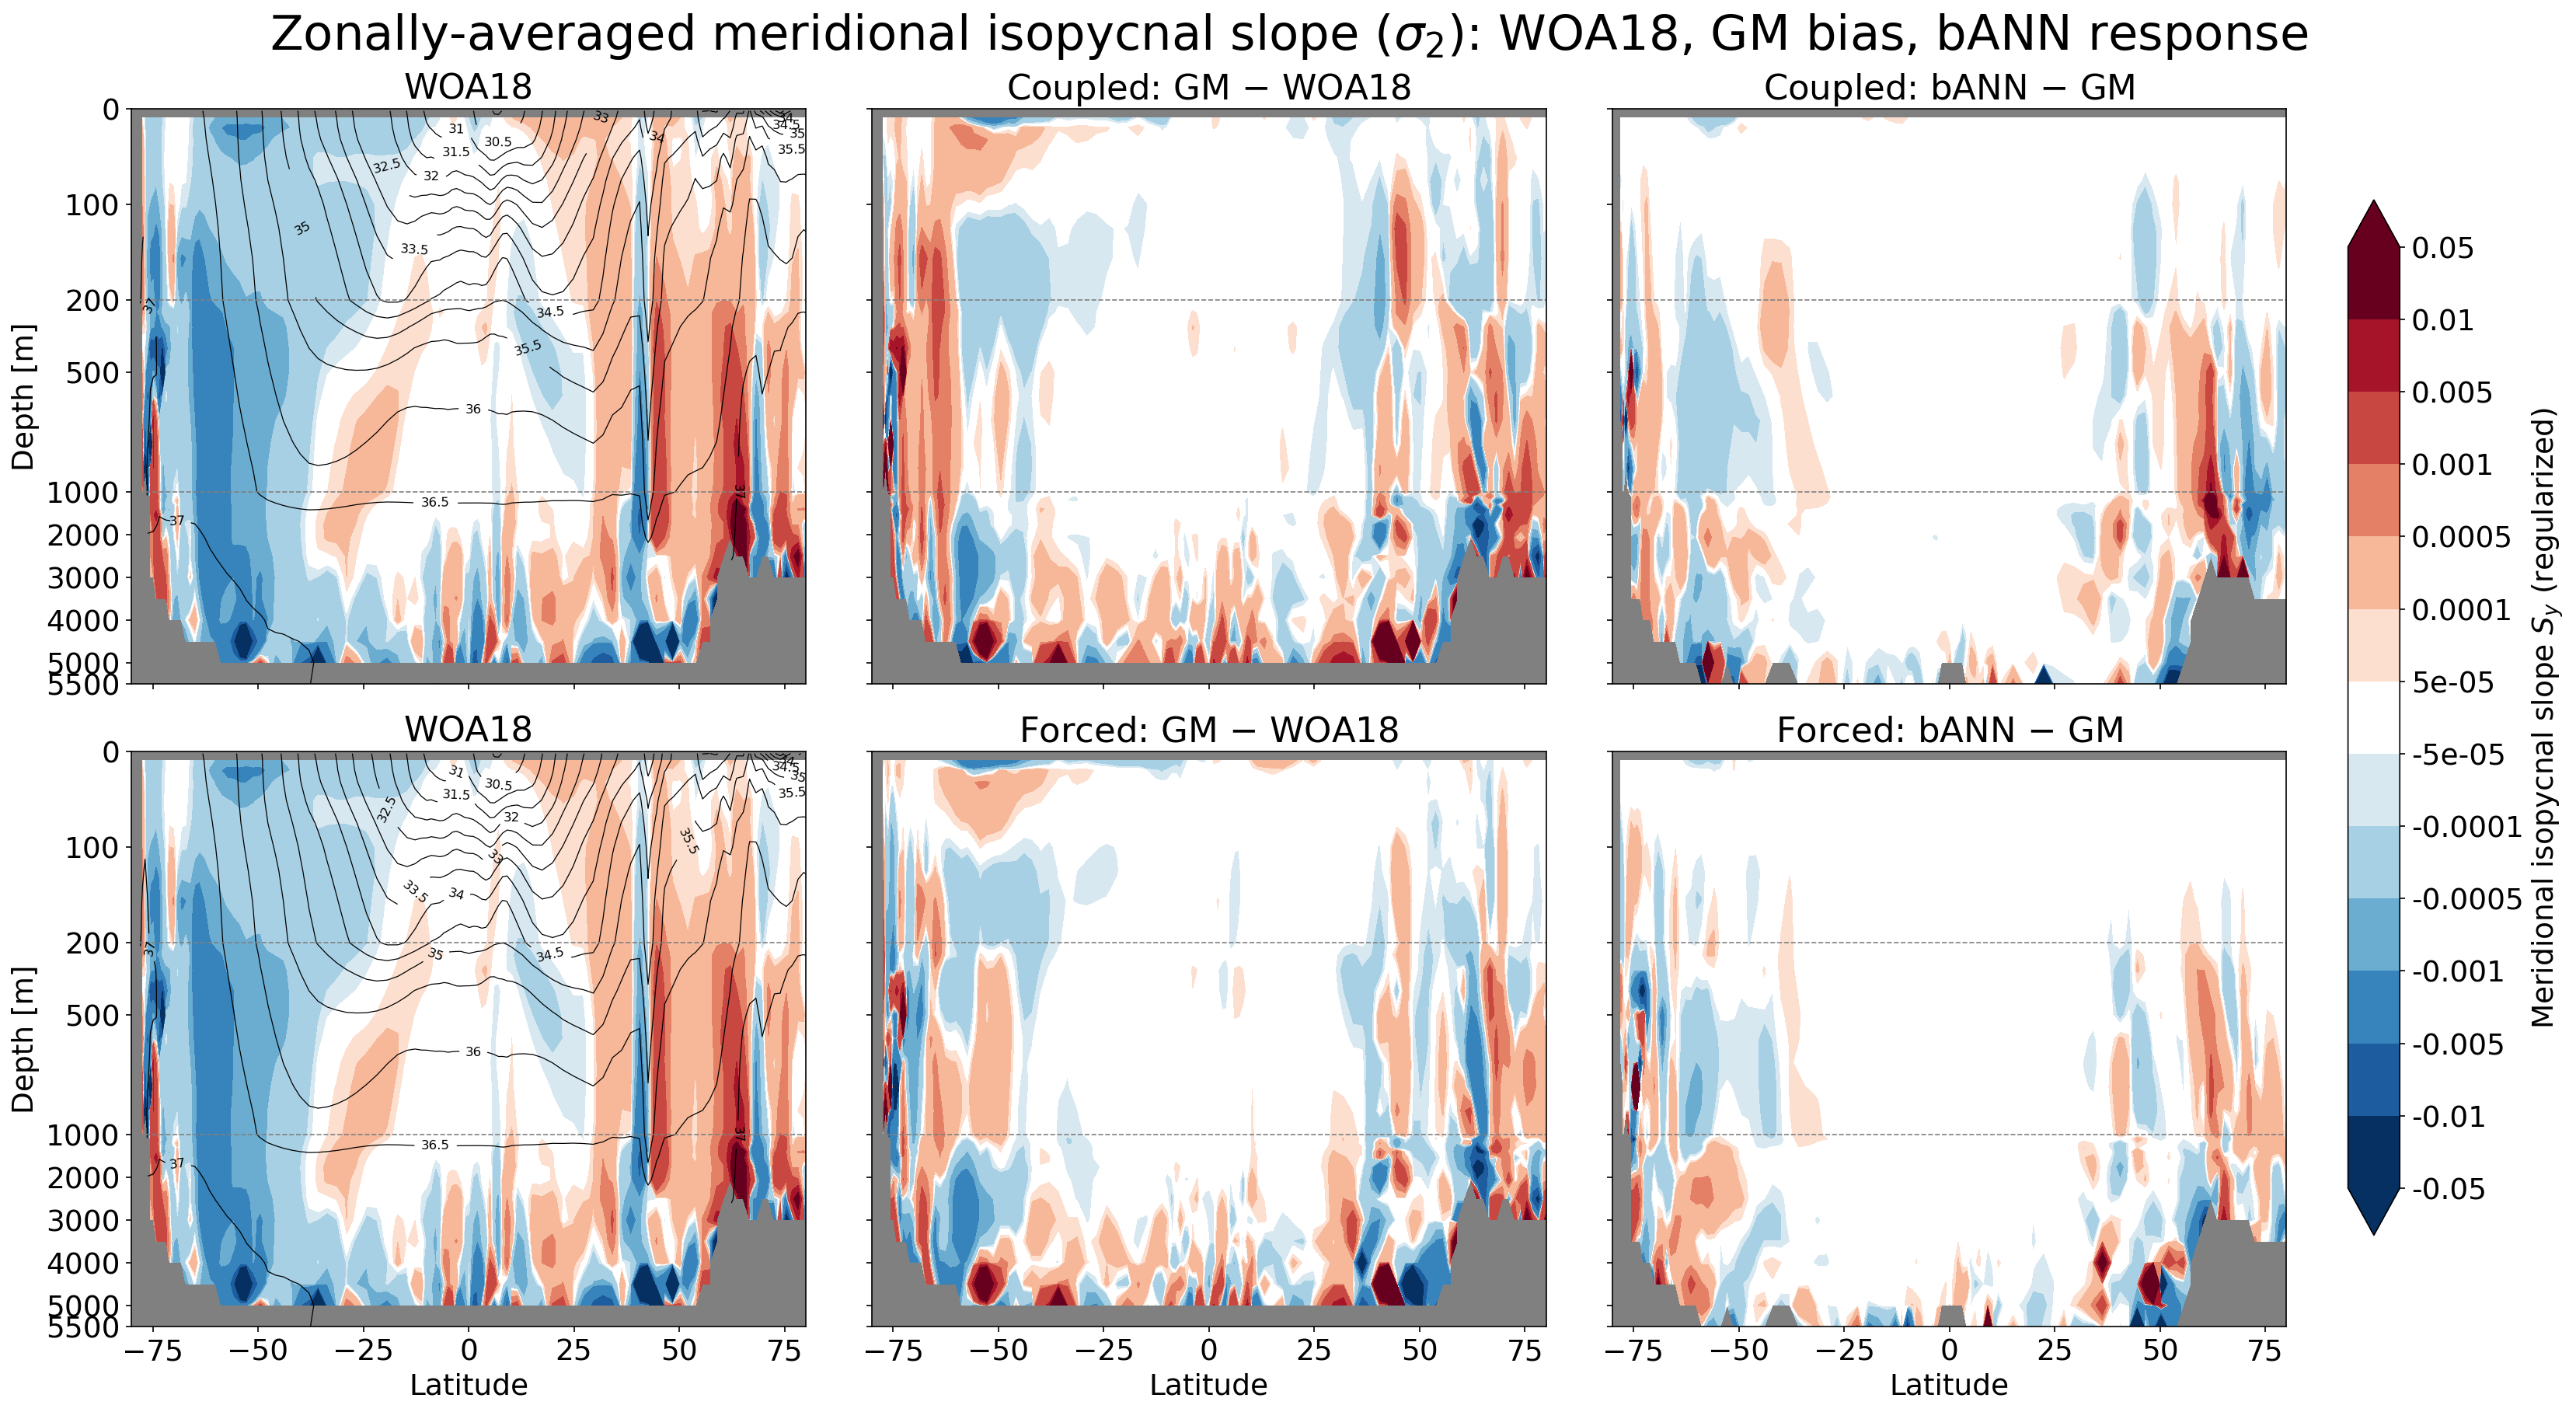

In [14]:
plot_slope_zonal()